# **Analyse du papier de recherche Center-Based 3D Object Detection and Tracking** 

*Auteur :* Erwan Ouabdesselam

*Abstract:* 3D object detection from LiDAR point clouds is a fundamental component of autonomous driving perception systems. CenterPoint proposes a center-based formulation that models objects as keypoints and regresses their full 3D bounding boxes from a bird's-eye-view (BEV) representation. This report analyzes the theoretical principles of the method, implements key components of the pipeline, evaluates the model on the nuScenes dataset, and provides a critical assessment of its strengths and limitations.

In [1]:
import os
import sys

import warnings
warnings.filterwarnings("ignore")

# Le framework CenterPoint s'attend à tourner depuis centerpoint/
REPO_ROOT      = os.path.abspath(os.path.join(os.path.dirname("__file__"), "centerpoint"))
PROJECT_ROOT   = os.path.abspath(os.path.dirname("__file__"))  # pour figures/, work_dirs/
os.chdir(REPO_ROOT)
sys.path.insert(0, REPO_ROOT)

print("Working directory:", os.getcwd())

import numpy as np
import torch
import matplotlib
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyArrowPatch
from matplotlib.lines import Line2D

from pathlib import Path
from IPython.display import Image, display
import imageio
from tqdm import tqdm

# Imports nuScenes
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import LidarPointCloud, Box
from pyquaternion import Quaternion

# Imports du framework det3d
from det3d.torchie import Config
from det3d.datasets import build_dataset
from det3d.models import build_detector
from det3d.torchie.trainer import load_checkpoint


# Choix du device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("PyTorch:", torch.__version__)

# Chemins — tout relatif à centerpoint/ sauf work_dirs/ et figures/
CFG_PATH     = "configs/nusc/voxelnet/nusc_centerpoint_voxelnet_0075voxel_fix_bn_z_flip.py"
CKPT_PATH    = os.path.join(PROJECT_ROOT, "work_dirs/nusc_centerpoint/epoch_20.pth")
DATA_ROOT    = "data/nuScenes"
VAL_PKL      = os.path.join(DATA_ROOT, "infos_val_10sweeps_withvelo_filter_True.pkl")
FIGURES_DIR  = os.path.join(PROJECT_ROOT, "figures")

# Chargement de la configuration du modèle
cfg = Config.fromfile(CFG_PATH)

cfg.data.val.root_path  = DATA_ROOT
cfg.data.val.info_path  = VAL_PKL
cfg.data.val.ann_file   = VAL_PKL
cfg.data.val.nsweeps    = 10

# Construction du dataset de validation
val_dataset = build_dataset(cfg.data.val)
print("Dataset size:", len(val_dataset))

# Construction du modèle
model = build_detector(cfg.model, train_cfg=None, test_cfg=cfg.test_cfg)

# Chargement des poids entraînés
load_checkpoint(model, CKPT_PATH, map_location="cpu")

model = model.to(DEVICE).eval()

# Informations sur l'architecture
print("Model loaded")
print("Reader:", type(model.reader).__name__)
print("Backbone:", type(model.backbone).__name__)
print("Neck:", type(model.neck).__name__)
print("Head:", type(model.bbox_head).__name__)

Working directory: /home/r1/Analysis_of_CenterPoint/centerpoint


no apex
No Tensorflow
Deformable Convolution not built!
Device: cuda
PyTorch: 2.4.1+cu118
10
Dataset size: 81
Use HM Bias:  -2.19
Model loaded
Reader: VoxelFeatureExtractorV3
Backbone: SpMiddleResNetFHD
Neck: RPN
Head: CenterHead


# **Introduction**

Autonomous driving systems rely on accurate 3D perception from LiDAR sensors, which provide sparse, irregular point clouds of the surrounding environment. Three challenges make this task significantly harder than 2D image detection: (i) most of the 3D space contains no measurements; (ii) objects appear with arbitrary orientations; and (iii) object classes span highly heterogeneous sizes, from bicycles to buses.

Many existing 3D detectors use anchors, predefined bounding-box candidates at fixed orientations, to hypothesize object locations. While effective in 2D where boxes align with image axes, this strategy is poorly suited to 3D: covering all plausible orientations requires a large number of anchors, increasing computational cost, complicating positive/negative sample assignment during training, and inflating the number of potential false positives.

CenterPoint addresses these issues by reformulating 3D detection as keypoint estimation. Instead of predicting oriented boxes directly, the model first detects object centers in a bird's-eye-view heatmap and regresses their geometric attributes from those locations. Since a point carries no intrinsic orientation, this representation eliminates the need to enumerate orientation hypotheses and substantially reduces the detector's search space.

The main contributions of CenterPoint are: (i) a center-based detection head compatible with any standard 3D backbone; (ii) an efficient two-stage refinement module using surface-point features; (iii) a unified detection-and-tracking framework via velocity estimation; and (iv) state-of-the-art results on both nuScenes and Waymo at the time of publication.


# **I. Analysis of the pipeline**

To better understand the architecture of CenterPoint, the overall pipeline can be decomposed into **four main components**, as illustrated in the diagram below that come from the paper. In the following sections, each component will be examined in detail to provide a clearer understanding of how the model processes LiDAR point cloud data to produce 3D object detections.


<p align="center">
<img src="figures/full_pipeline.png" width="800">
</p>

### **LiDAR measurements and frame representation**

A LiDAR (Light Detection and Ranging) sensor measures distances by emitting laser pulses and 
recording the time it takes for the reflected signal to return to the sensor. As the sensor 
rotates, successive laser beams scan the surrounding environment and generate a set of 3D 
points describing the scene. This collection of points is commonly referred to as a **point cloud**.

In the nuScenes dataset, each LiDAR frame is stored as a set of points:

$$P = \{(x_i, y_i, z_i, r_i)\}_{i=1}^{N}$$

where $x_i, y_i, z_i$ denote the spatial coordinates of the reflection and $r_i$ represents 
the reflectance intensity returned by the laser. In practice, CenterPoint additionally 
aggregates 10 consecutive sweeps, adding a temporal offset $\Delta t$ as a fifth feature 
to each point.

All points are expressed in the **ego-vehicle coordinate system**, centered on the LiDAR 
sensor mounted on the vehicle. In this coordinate frame:

- $x$ corresponds to the forward direction of the vehicle  
- $y$ corresponds to the lateral direction (left–right)  
- $z$ corresponds to the vertical direction  

This coordinate system provides a consistent spatial reference for representing the scene 
and predicting the **3D bounding boxes of surrounding objects**.

In practice, each LiDAR frame contains tens or hundreds of thousands of points describing 
surfaces such as roads, vehicles, buildings, and vegetation. Each point corresponds to a 
single laser reflection captured by the sensor.

In [22]:
# Charger le premier sample
nusc = NuScenes(
    version='v1.0-mini',
    dataroot="data/nuScenes",
    verbose=True)

sample_idx = 22
data = val_dataset[sample_idx]
info = val_dataset._nusc_infos[sample_idx]
sample_token = info["token"]
sample = nusc.get("sample", sample_token)

# Extraire le nuage de points (N, 5) : x, y, z, intensity, delta_t
points = data[0]['points']  # numpy array (N, 5)
print(f"Nuage de points shape : {points.shape}")
print(f"  x   : [{points[:,0].min():.1f}, {points[:,0].max():.1f}] m")
print(f"  y   : [{points[:,1].min():.1f}, {points[:,1].max():.1f}] m")
print(f"  z   : [{points[:,2].min():.1f}, {points[:,2].max():.1f}] m")
print(f"  int : [{points[:,3].min():.3f}, {points[:,3].max():.3f}]")
print(f"  Δt  : [{points[:,4].min():.3f}, {points[:,4].max():.3f}]")

# Valeurs uniques de Δt → nombre de sweeps effectifs
dt_vals = np.unique(np.round(points[:,4], 3))
print(f"\nNombre de sweeps distincts (Δt uniques) : {len(dt_vals)}")
print(f"Valeurs Δt : {dt_vals}")


Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.7 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.
Nuage de points shape : (277895, 5)
  x   : [-87.2, 48.3] m
  y   : [-105.6, 101.6] m
  z   : [-10.4, 13.5] m
  int : [0.000, 255.000]
  Δt  : [0.000, 0.452]

Nombre de sweeps distincts (Δt uniques) : 10
Valeurs Δt : [0.    0.052 0.101 0.152 0.202 0.252 0.302 0.352 0.402 0.452]


In our example, `sample_idx = 22` contains approximately **277,895 LiDAR points** across **9 object classes**, including cars, pedestrians, a bicycle, a motorcycle, a truck, and a traffic cone — making it a representative and diverse urban scene for illustrating the full CenterPoint pipeline.

Each point is described by five features: $(x, y, z, \text{intensity}, \Delta t)$

- $x, y, z$ are the spatial coordinates of the point, spanning $x \in [-87.2, 48.3]$ m, $y \in [-105.6, 101.6]$ m, $z \in [-10.4, 13.5]$ m
- $\text{intensity}$ represents the reflectance of the surface hit by the laser beam
- $\Delta t \in [0, 0.452]$ indicates the relative timestamp of the LiDAR sweep from which the point originates

The 10 discrete values of $\Delta t$ (0, 0.052, 0.101, ..., 0.452) confirm that exactly **10 consecutive sweeps** have been aggregated into this single input frame, as expected from CenterPoint's multi-sweep setup.

### **Bird's Eye View representation**

CenterPoint performs detection in **Bird's Eye View (BEV)**.

The point cloud is projected onto the ground plane by ignoring the vertical coordinate $z$.  
In this representation, objects appear as oriented rectangles and distances are preserved.

This projection is particularly suitable for autonomous driving scenes. Most objects of interest (cars, pedestrians, cyclists) lie on the road surface and primarily move in the horizontal plane. Their orientation therefore corresponds to a **yaw rotation around the vertical axis**, while the vertical dimension contains relatively little information for localization.

As a result, projecting the scene into BEV removes the vertical dimension while preserving most of the geometric information relevant for object detection. Note that the
z-axis information is not entirely discarded, it is recovered later through a dedicated
height-above-ground regression head in the detection pipeline.

The figure below shows a LiDAR frame together with the ground-truth 3D bounding boxes projected in BEV.

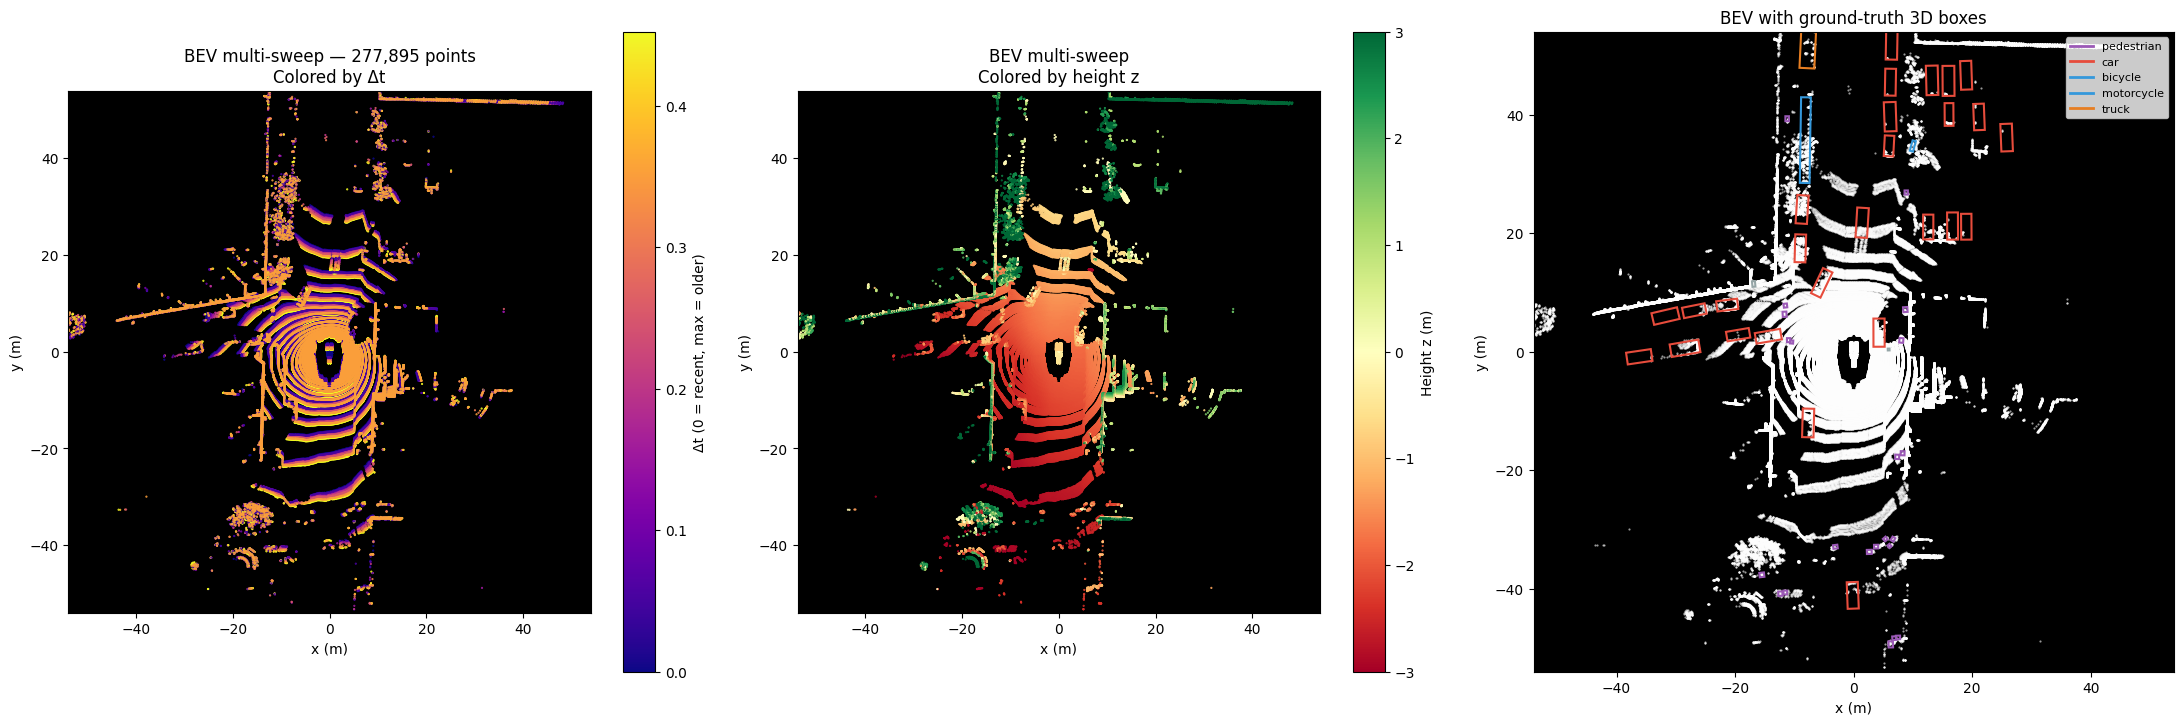

In [23]:
from matplotlib.lines import Line2D

# Helper function to extract Ground Truth annotations
def get_sample_boxes_in_lidar(nusc, sample):
    """
    Return all annotation boxes for a sample, transformed into the LiDAR sensor frame.
    """
    lidar_token = sample["data"]["LIDAR_TOP"]
    lidar_data = nusc.get("sample_data", lidar_token)

    cs = nusc.get("calibrated_sensor", lidar_data["calibrated_sensor_token"])
    ep = nusc.get("ego_pose", lidar_data["ego_pose_token"])

    boxes = []
    for ann_token in sample["anns"]:
        ann = nusc.get("sample_annotation", ann_token)

        box = Box(
            ann["translation"],
            ann["size"],
            Quaternion(ann["rotation"]),
            name=ann["category_name"]
        )

        # global → ego
        box.translate(-np.array(ep["translation"]))
        box.rotate(Quaternion(ep["rotation"]).inverse)

        # ego → sensor
        box.translate(-np.array(cs["translation"]))
        box.rotate(Quaternion(cs["rotation"]).inverse)

        boxes.append(box)

    return boxes


# Extract boxes
boxes = get_sample_boxes_in_lidar(nusc, sample)


# BEV visualization
fig, axes = plt.subplots(1, 3, figsize=(22, 7))


# --- 1 : colored by Δt ---
ax = axes[0]

dt = points[:, 4]

sc = ax.scatter(
    points[:, 0],
    points[:, 1],
    c=dt,
    s=0.3,
    cmap="plasma",
    vmin=0,
    vmax=dt.max(),
    rasterized=True
)

plt.colorbar(sc, ax=ax, label="Δt (0 = recent, max = older)")

ax.set_xlim(-54, 54)
ax.set_ylim(-54, 54)
ax.set_aspect("equal")

ax.set_title(f"BEV multi-sweep — {points.shape[0]:,} points\nColored by Δt")

ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")

ax.set_facecolor("black")
ax.grid(False)


# --- 2 : colored by height z ---
ax2 = axes[1]

z = points[:, 2]

sc2 = ax2.scatter(
    points[:, 0],
    points[:, 1],
    c=z,
    s=0.3,
    cmap="RdYlGn",
    vmin=-3,
    vmax=3,
    rasterized=True
)

plt.colorbar(sc2, ax=ax2, label="Height z (m)")

ax2.set_xlim(-54, 54)
ax2.set_ylim(-54, 54)
ax2.set_aspect("equal")

ax2.set_title("BEV multi-sweep\nColored by height z")

ax2.set_xlabel("x (m)")
ax2.set_ylabel("y (m)")

ax2.set_facecolor("black")
ax2.grid(False)


# --- 3 : point cloud + ground truth boxes ---
ax3 = axes[2]

ax3.scatter(points[:, 0], points[:, 1], s=0.3, c="white", alpha=0.6)

COLOR_MAP = {
    "car": "#e74c3c",
    "truck": "#e67e22",
    "bus": "#f1c40f",
    "trailer": "#f1c40f",
    "construction_vehicle": "#e67e22",
    "barrier": "#2ecc71",
    "motorcycle": "#3498db",
    "bicycle": "#3498db",
    "pedestrian": "#9b59b6",
    "traffic_cone": "#9b59b6",
}


legend_entries = {}

for box in boxes:


    cat = box.name.lower()

    cat_mapped = None
    for key in COLOR_MAP:
        if key in cat:
            cat_mapped = key
            break

    color = COLOR_MAP.get(cat_mapped, "#95a5a6")

    corners = box.bottom_corners()[:2, :]

    rect = plt.Polygon(
        corners.T,
        closed=True,
        fill=False,
        edgecolor=color,
        linewidth=1.5
    )

    ax3.add_patch(rect)

    if cat_mapped and cat_mapped not in legend_entries:
        legend_entries[cat_mapped] = color


handles = [
    Line2D([0], [0], color=c, lw=2, label=n)
    for n, c in legend_entries.items()
]

ax3.legend(handles=handles, loc="upper right", fontsize=8, framealpha=0.8)

ax3.set_xlim(-54, 54)
ax3.set_ylim(-54, 54)
ax3.set_aspect("equal")

ax3.set_title("BEV with ground-truth 3D boxes")

ax3.set_xlabel("x (m)")
ax3.set_ylabel("y (m)")

ax3.set_facecolor("black")
ax3.grid(False)


plt.tight_layout()
plt.show()

### **Temporal structure**

nuScenes provides sequences of LiDAR frames. The LiDAR sensor operates at approximately **20 Hz**, meaning a new point cloud is captured every **50 milliseconds**. 

This temporal structure allows models such as CenterPoint to estimate **object velocities** and perform **tracking across frames**.

The following animation shows consecutive LiDAR frames together with their ground-truth bounding boxes.

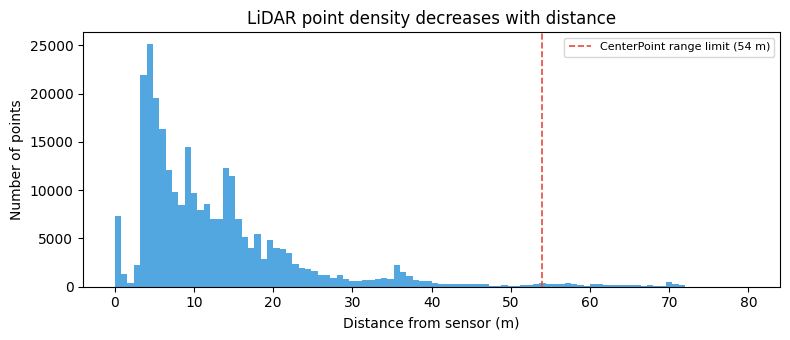

In [24]:
distances = np.linalg.norm(points[:, :2], axis=1)

fig, ax = plt.subplots(figsize=(8, 3.5))

ax.hist(
    distances,
    bins=100,
    range=(0, 80),
    color="#3498db",
    edgecolor="none",
    alpha=0.85
)

ax.set_xlabel("Distance from sensor (m)")
ax.set_ylabel("Number of points")

ax.set_title("LiDAR point density decreases with distance")

ax.axvline(
    x=54,
    color="#e74c3c",
    linestyle="--",
    linewidth=1.2,
    label="CenterPoint range limit (54 m)"
)

ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## **2. Voxelization of the LiDAR Point Cloud**

### **Motivation**

A LiDAR sensor captures the environment as a **point cloud**: a set of points in 3D space. Unlike images, point clouds are **unordered and irregular**, there is no underlying grid structure and the number of points varies from frame to frame.

Convolutional neural networks, however, are designed to process **structured inputs arranged on regular grids**. To apply them to LiDAR data, the point cloud must first be converted into a structured spatial representation.

**Voxelization** is the standard solution: it discretizes the 3D space into small volumetric cells called **voxels**, producing a regular grid that CNNs can process.

---

### **Principle**

Voxelization divides the 3D space surrounding the ego vehicle into a regular grid. Each voxel is defined by a spatial resolution $(\Delta x, \Delta y, \Delta z)$. Each point $(x, y, z)$ is assigned to the voxel whose cell it falls into along each axis.

All points falling inside the same voxel are grouped together. In practice, only voxels that contain at least one point are stored, resulting in a **sparse representation** that avoids allocating memory for empty space.

---

### **Two variants in the CenterPoint paper**

The CenterPoint paper evaluates two voxelization strategies:

**VoxelNet-style (3D voxels)**  
The 3D space is discretized along all three spatial dimensions $(x, y, z)$. Each voxel aggregates the points it contains into a feature vector, processed by a **sparse 3D convolutional backbone** that preserves the full vertical geometry of the scene before projecting onto a BEV feature map.

**PointPillars-style (pillars)**  
The vertical dimension is collapsed: the space is discretized only along the ground plane $(x, y)$, and each cell corresponds to a vertical column called a **pillar**. This enables the use of **2D convolutional networks**, which are significantly faster but lose some vertical geometric information.

The paper shows that the VoxelNet variant achieves higher accuracy, while the PointPillars variant is faster. In this notebook we focus on the **VoxelNet formulation**.

---

### **CenterPoint implementation**

CenterPoint uses the following parameters for the VoxelNet variant:

| Parameter | Value | Description |
|---|---|---|
| Voxel size | [0.075, 0.075, 0.2] m | $(\Delta x, \Delta y, \Delta z)$ spatial resolution |
| Point cloud range | [−54, −54, −5, 54, 54, 3] m | Detection zone |
| Max points per voxel | 10 | If exceeded, points are randomly subsampled |
| Max voxels | 120 000 (test) | GPU memory cap |

Each point carries **5 features**: $(x, y, z, \text{intensity}, \Delta t)$. The $\Delta t$ feature encodes the temporal offset of the point relative to the current sweep, and is specific to the multi-sweep aggregation used by CenterPoint (10 sweeps).

Once points are grouped into voxels, only **94,598** voxels out of a theoretical grid of 
**1440 × 1440 × 40 = 82,944,000** are occupied, a sparsity of **0.114%**.

In [25]:
from det3d.ops.point_cloud.point_cloud_ops import points_to_voxel

VOXEL_SIZE = [0.075, 0.075, 0.2]
PC_RANGE   = [-54, -54, -5, 54, 54, 3]
MAX_POINTS = 10
MAX_VOXELS = 120000

voxels, coordinates, num_points_per_voxel = points_to_voxel(
    points, VOXEL_SIZE, PC_RANGE, MAX_POINTS,
    reverse_index=True, max_voxels=MAX_VOXELS
)

# Dimensions théoriques de la grille
grid_x = int((PC_RANGE[3] - PC_RANGE[0]) / VOXEL_SIZE[0])  # 1440
grid_y = int((PC_RANGE[4] - PC_RANGE[1]) / VOXEL_SIZE[1])  # 1440
grid_z = int((PC_RANGE[5] - PC_RANGE[2]) / VOXEL_SIZE[2])  # 40
total_voxels = grid_x * grid_y * grid_z

sparsity = voxels.shape[0] / total_voxels * 100

print(f"Output shapes:")
print(f"  voxels      : {voxels.shape}  → (N_voxels, max_points, 5 features)")
print(f"  coordinates : {coordinates.shape}  → (N_voxels, 3) indices (z, y, x)")
print(f"  num_points  : {num_points_per_voxel.shape}")
print()
print(f"Theoretical grid : {grid_x} × {grid_y} × {grid_z} = {total_voxels:,} voxels")
print(f"Occupied voxels  : {voxels.shape[0]:,} / {MAX_VOXELS:,}")
print(f"Sparsity         : {sparsity:.4f}% occupied  → extremely sparse")
print()
print(f"Points per voxel — min: {num_points_per_voxel.min()}  "
      f"max: {num_points_per_voxel.max()}  "
      f"mean: {num_points_per_voxel.mean():.2f}")


Output shapes:
  voxels      : (94598, 10, 5)  → (N_voxels, max_points, 5 features)
  coordinates : (94598, 3)  → (N_voxels, 3) indices (z, y, x)
  num_points  : (94598,)

Theoretical grid : 1440 × 1440 × 40 = 82,944,000 voxels
Occupied voxels  : 94,598 / 120,000
Sparsity         : 0.1141% occupied  → extremely sparse

Points per voxel — min: 1  max: 10  mean: 2.56


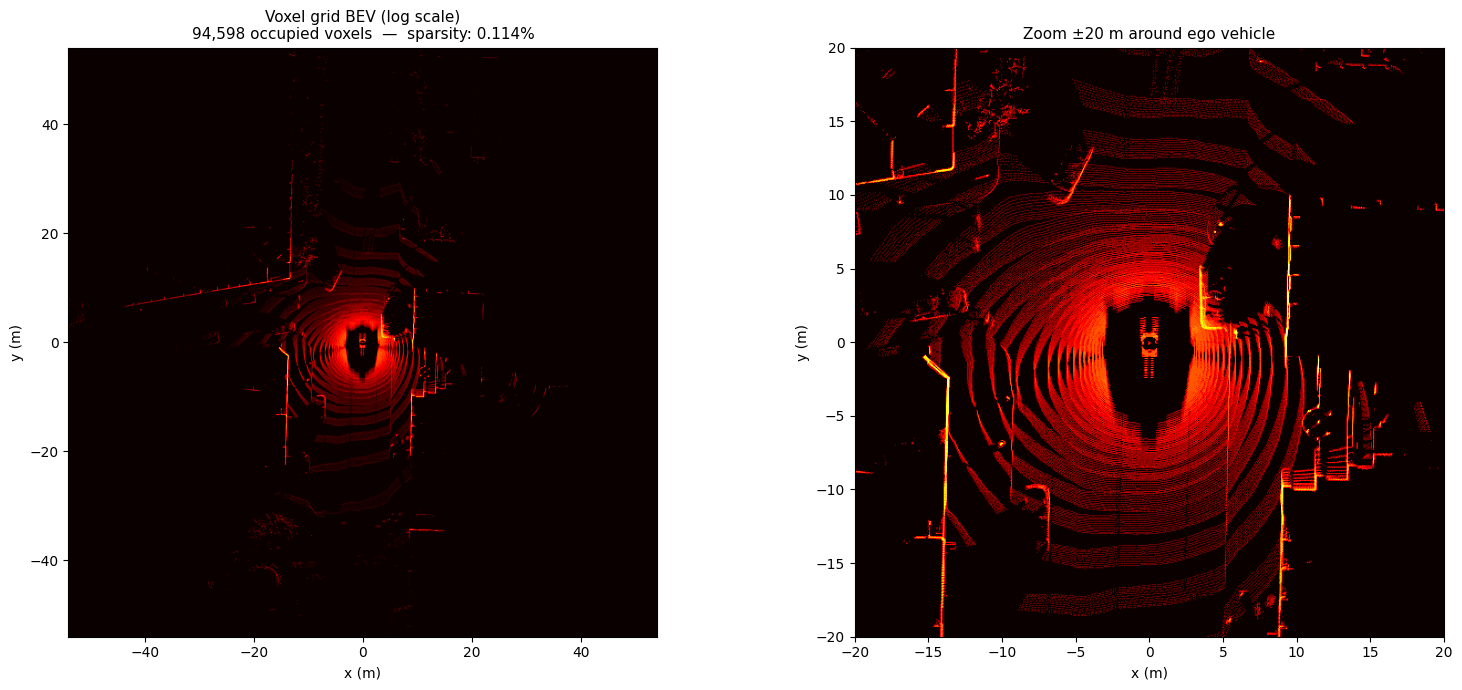

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Construire la grille BEV (projection selon z, somme des points)
bev_grid = np.zeros((grid_y, grid_x), dtype=np.float32)
for coord, npts in zip(coordinates, num_points_per_voxel):
    y_idx, x_idx = int(coord[1]), int(coord[2])
    if 0 <= y_idx < grid_y and 0 <= x_idx < grid_x:
        bev_grid[y_idx, x_idx] += npts

extent = [PC_RANGE[0], PC_RANGE[3], PC_RANGE[1], PC_RANGE[4]]

# Vue globale
ax = axes[0]
ax.imshow(np.log1p(bev_grid), cmap='hot', origin='lower', extent=extent, aspect='equal')
ax.set_title(f'Voxel grid BEV (log scale)\n{voxels.shape[0]:,} occupied voxels  —  sparsity: {sparsity:.3f}%',
             fontsize=11)
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')

# Zoom ±20 m autour du véhicule ego
ax2 = axes[1]
zoom_m = 20
cx, cy = grid_x // 2, grid_y // 2
zpx = int(zoom_m / VOXEL_SIZE[0])
sub = bev_grid[cy - zpx:cy + zpx, cx - zpx:cx + zpx]
ax2.imshow(np.log1p(sub), cmap='hot', origin='lower',
           extent=[-zoom_m, zoom_m, -zoom_m, zoom_m], aspect='equal')
ax2.set_title(f'Zoom ±{zoom_m} m around ego vehicle', fontsize=11)
ax2.set_xlabel('x (m)'); ax2.set_ylabel('y (m)')

plt.tight_layout()
plt.show()


The voxel grid reveals the characteristic structure of a LiDAR point cloud. The concentric 
ring patterns reflect the rotational scanning mechanism of the sensor: each ring corresponds 
to one full revolution, and the spacing between rings increases with distance as point density 
decreases.

The zoom around the ego vehicle confirms that fine geometric structures, walls, building 
facades, and parked vehicles are well preserved at the 7.5 cm resolution used by CenterPoint.

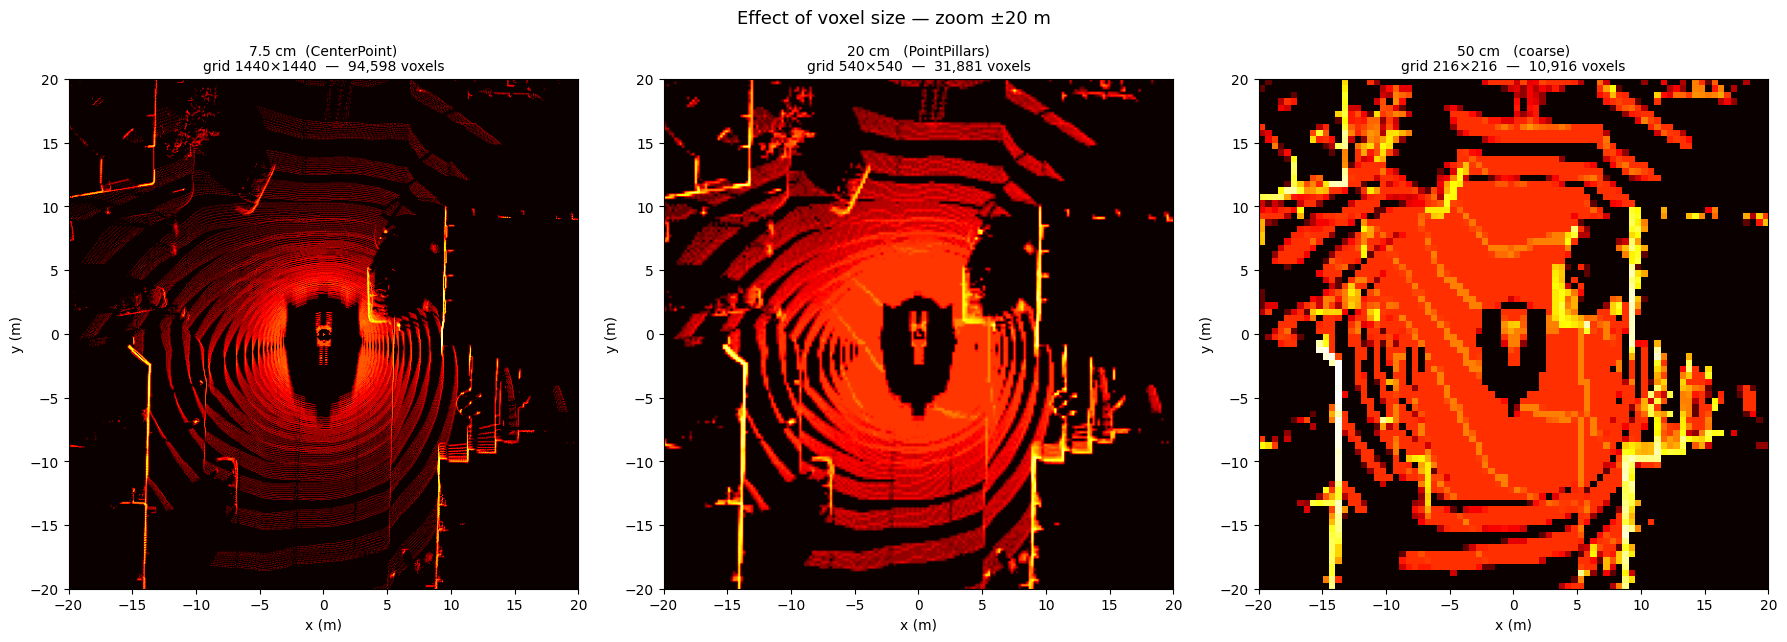

In [27]:
SIZES = {
    '7.5 cm  (CenterPoint)': [0.075, 0.075, 0.2],
    '20 cm   (PointPillars)': [0.20,  0.20,  0.2],
    '50 cm   (coarse)':       [0.50,  0.50,  0.2],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (label, vs) in zip(axes, SIZES.items()):
    vox_i, coo_i, npts_i = points_to_voxel(
        points, vs, PC_RANGE, MAX_POINTS,
        reverse_index=True, max_voxels=MAX_VOXELS
    )

    gx = int((PC_RANGE[3] - PC_RANGE[0]) / vs[0])
    gy = int((PC_RANGE[4] - PC_RANGE[1]) / vs[1])
    grid_i = np.zeros((gy, gx), dtype=np.float32)
    for coord, npts in zip(coo_i, npts_i):
        yi, xi = int(coord[1]), int(coord[2])
        if 0 <= yi < gy and 0 <= xi < gx:
            grid_i[yi, xi] += npts

    # Zoom ±20 m
    zoom_m = 20
    cx_i, cy_i = gx // 2, gy // 2
    zpx_i = int(zoom_m / vs[0])
    sub_i = grid_i[cy_i - zpx_i:cy_i + zpx_i, cx_i - zpx_i:cx_i + zpx_i]

    ax.imshow(np.log1p(sub_i), cmap='hot', origin='lower',
              extent=[-zoom_m, zoom_m, -zoom_m, zoom_m], aspect='equal')
    ax.set_title(f'{label}\ngrid {gx}×{gy}  —  {vox_i.shape[0]:,} voxels', fontsize=10)
    ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')

plt.suptitle('Effect of voxel size — zoom ±20 m', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


The three grids illustrate the resolution trade-off introduced by the voxel size parameter:

- **7.5 cm (CenterPoint default):** Individual scan rings remain distinct and fine geometric 
structures are preserved. A pedestrian or a narrow pole occupies several voxels, making it 
detectable.
- **20 cm (PointPillars default):** The geometry is still recognizable but scan rings begin 
to merge. Small objects start to blur into their surroundings. The grid is 7× smaller 
(540×540), which reduces memory and computation significantly.
- **50 cm (coarse):** Geometric detail is largely destroyed. Distinct structures fuse into 
large blocks. At this resolution, detecting small objects such as pedestrians or cyclists 
becomes unreliable.





### **Voxel Feature Encoding — MeanVFE**

After voxelization, each occupied voxel contains a variable number of points (between 1 and 
`max_points=10`), all padded to the same size with zeros. The backbone cannot work with this 
variable-length structure — it needs **exactly one feature vector per voxel**.

This is the role of the **Voxel Feature Extractor (VFE)**: aggregate the points inside each 
voxel into a single fixed-size vector.

CenterPoint uses the simplest possible aggregation: the **mean** of the features of all real 
points in the voxel (padding zeros are excluded using `num_points`):

$$f_{\text{voxel}} = \frac{1}{k} \sum_{i=1}^{k} p_i \quad \text{where } k \text{ is the actual number of points in the voxel}$$

This operation has **no learnable parameters** — it is a pure averaging step.

In [28]:
import torch

voxel_tensor   = torch.tensor(voxels, dtype=torch.float32).to(DEVICE)
coords_tensor  = torch.tensor(coordinates, dtype=torch.int32).to(DEVICE)
num_pts_tensor = torch.tensor(num_points_per_voxel, dtype=torch.int32).to(DEVICE)

# Ajouter l'index de batch (batch_size=1)
batch_idx    = torch.zeros((coords_tensor.shape[0], 1), dtype=torch.int32, device=DEVICE)
batch_coords = torch.cat([batch_idx, coords_tensor], dim=1)  # (N_vox, 4)

with torch.no_grad():
    encoded = model.reader(voxel_tensor, num_pts_tensor, batch_coords)

print(f"Entrée  : {voxel_tensor.shape}  — (N_vox, max_points, 5)")
print(f"Sortie  : {encoded.shape}        — (N_vox, 5)")
print()

# Vérification manuelle sur 3 voxels
print("Vérification MeanVFE :")
print(f"{'Voxel':<8} {'k pts':<8} {'Moyenne manuelle':<45} {'Sortie reader':<45} {'OK'}")
print("-" * 120)
for idx in [0, 100, 1000]:
    k          = num_points_per_voxel[idx]
    manual     = voxels[idx, :k, :].mean(axis=0)
    from_model = encoded[idx].cpu().numpy()
    ok         = np.allclose(manual, from_model, atol=1e-4)
    print(f"{idx:<8} {k:<8} {str(np.round(manual, 4)):<45} {str(np.round(from_model, 4)):<45} {'✓' if ok else '✗'}")


Entrée  : torch.Size([94598, 10, 5])  — (N_vox, max_points, 5)
Sortie  : torch.Size([94598, 5])        — (N_vox, 5)

Vérification MeanVFE :
Voxel    k pts    Moyenne manuelle                              Sortie reader                                 OK
------------------------------------------------------------------------------------------------------------------------
0        10       [-3.2103 -0.1112 -1.9098  3.8     0.0504]     [-3.2103 -0.1112 -1.9098  3.8     0.0504]     ✓
100      1        [-9.7892  0.3212 -2.3349 11.      0.    ]     [-9.7892  0.3212 -2.3349 11.      0.    ]     ✓
1000     1        [-9.2026  3.4498 -2.111   6.      0.    ]     [-9.2026  3.4498 -2.111   6.      0.    ]     ✓


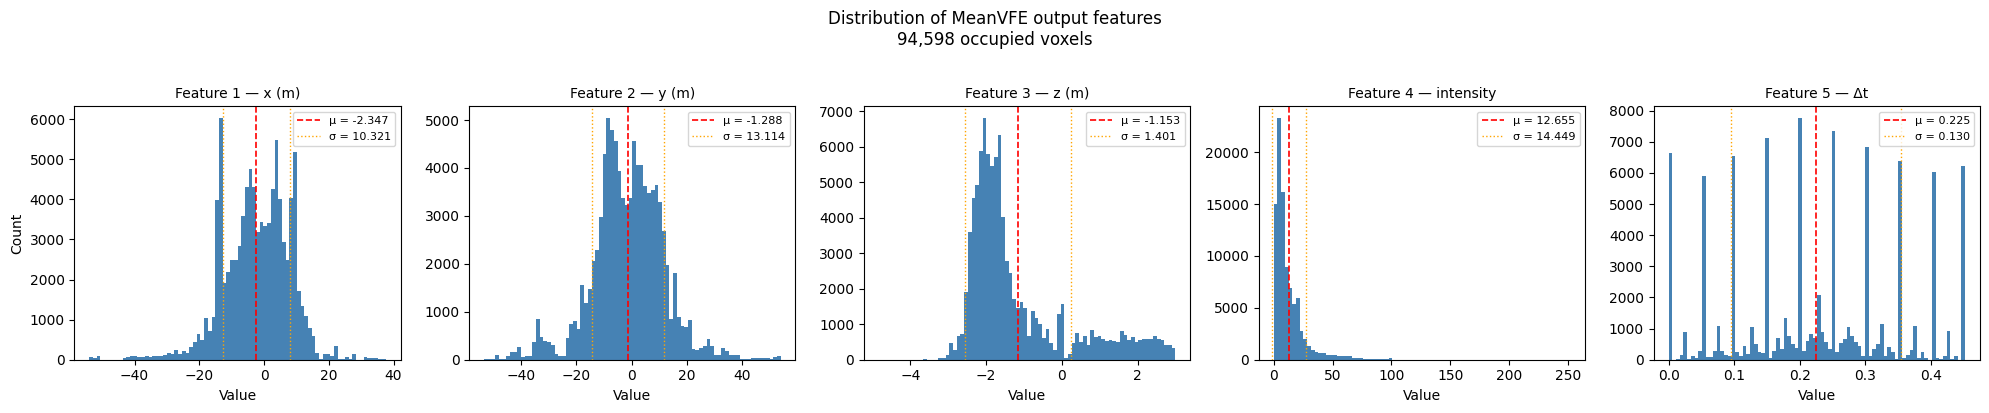

In [29]:
encoded_np = encoded.cpu().numpy()  # (N_vox, 5)
FEATURE_NAMES = ['x (m)', 'y (m)', 'z (m)', 'intensity', 'Δt']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, (ax, fname) in enumerate(zip(axes, FEATURE_NAMES)):
    vals = encoded_np[:, i]
    ax.hist(vals, bins=80, color='steelblue', edgecolor='none')
    ax.axvline(vals.mean(), color='red', linestyle='--', linewidth=1.2,
               label=f'μ = {vals.mean():.3f}')
    ax.axvline(vals.mean() - vals.std(), color='orange', linestyle=':', linewidth=1)
    ax.axvline(vals.mean() + vals.std(), color='orange', linestyle=':', linewidth=1,
               label=f'σ = {vals.std():.3f}')
    ax.set_title(f'Feature {i+1} — {fname}', fontsize=10)
    ax.set_xlabel('Value'); ax.set_ylabel('Count' if i == 0 else '')
    ax.legend(fontsize=8)

plt.suptitle(f'Distribution of MeanVFE output features\n'
             f'{encoded_np.shape[0]:,} occupied voxels', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


The verification confirms that the reader output is exactly the per-voxel mean of the raw 
point features, no transformation is applied.

The feature distributions reveal several properties of the encoded representation:

- **x** ($\mu = -2.35$ m, $\sigma = 10.32$ m) and **y** ($\mu = -1.29$ m, $\sigma = 13.11$ m) 
are slightly off-center, reflecting the actual position of the ego vehicle within the scene. 
Both features span the full detection range $[-54, 54]$ m, with higher density close to the 
ego vehicle where point coverage is denser.
- **z** ($\mu = -1.15$ m, $\sigma = 1.40$ m) shows two distinct peaks: one around $-2$ m 
corresponding to ground-level returns, and one around $-0.5$ m corresponding to vehicle 
rooftops. The distribution spans $[-4, 3]$ m, consistent with the configured detection 
range $[-5, 3]$ m.
- **intensity** ($\mu = 12.66$, $\sigma = 14.45$) is strongly right-skewed: most surfaces 
produce weak returns, while a small number of highly reflective surfaces such as road 
markings and traffic signs produce strong peaks near 255.
- **$\Delta t$** ($\mu = 0.225$, $\sigma = 0.130$) shows exactly 10 discrete peaks, one per 
aggregated sweep, each contributing a roughly equal number of voxels.

These 5-dimensional voxel features, together with their 3D coordinates, are passed as a 
sparse tensor to the backbone.

## **3. Sparse 3D Backbone and 2D Neck**

### **3D Backbone**

#### **Motivation**

After the MeanVFE, we have a set of ~94k voxel feature vectors positioned in a 3D grid of 
**1440 × 1440 × 40** cells. The backbone must process this 3D structure and produce a 
compact 2D representation that the detection head can work with.

A standard dense 3D CNN would need to process all 83 million cells of the grid, the vast 
majority of which are empty. CenterPoint instead uses a **sparse 3D convolutional network** 
that only computes on occupied voxels.


#### **Architecture**

The backbone progressively downsamples the 3D grid through 5 blocks while increasing the 
number of feature channels. At the end, the remaining depth dimension is collapsed to 
produce a dense BEV feature map.
```
Input : sparse (~94k voxels, 5 ch)  →  grid [40, 1440, 1440]
  ↓  Block 1 :   5 →  16 ch  →  grid [40, 1440, 1440]  (no downsampling)
  ↓  Block 2 :  16 →  32 ch  →  grid [20,  720,  720]  (stride 2)
  ↓  Block 3 :  32 →  64 ch  →  grid [10,  360,  360]  (stride 2)
  ↓  Block 4 :  64 → 128 ch  →  grid [ 5,  180,  180]  (stride 2)
  ↓  Block 5 : 128 → 128 ch  →  grid [ 2,  180,  180]  (stride 2 on z only)
  ↓  reshape  : 2 × 128 ch   →  256 ch
Output : (1, 256, 180, 180)  —  dense BEV feature map
```

Each downsampling step halves the resolution while doubling the number of feature channels.

The final step collapses the last 2 depth slices by **concatenating them along the channel 
dimension** — no geometric information is discarded, it is simply repackaged as additional 
channels. Each pixel in the output BEV feature map covers a **0.6 m × 0.6 m** area 
(108 m / 180 px).


In [30]:
# input_shape = (W, H, D) = (x_size, y_size, z_size)
input_shape = [1440, 1440, 40]

with torch.no_grad():
    bev_features, _ = model.backbone(encoded, batch_coords,
                                     batch_size=1, input_shape=input_shape)

print(f"Entrée  : sparse tensor  ({encoded.shape[0]:,} voxels, {encoded.shape[1]} ch)")
print(f"          grille 3D     : [40, 1440, 1440]")
print(f"Sortie  : {bev_features.shape}")
print(f"          résolution BEV : {108/180:.2f} m/pixel")
print(f"          couverture     : {int(180 * 108/180)} m × {int(180 * 108/180)} m")


Entrée  : sparse tensor  (94,598 voxels, 5 ch)
          grille 3D     : [40, 1440, 1440]
Sortie  : torch.Size([1, 256, 180, 180])
          résolution BEV : 0.60 m/pixel
          couverture     : 108 m × 108 m




### **2D Neck**

#### **Role**

The 2D neck takes the BEV feature map produced by the backbone **(1, 256, 180, 180)** and 
enriches it with **multi-scale context** before passing it to the detection head.

The backbone produces features at a single resolution (0.6 m/pixel). This is sufficient 
for large objects like trucks or buses, but small objects like pedestrians or cyclists 
require finer-scale context. The neck addresses this by processing the BEV map through 
several convolutional blocks at different strides and then **concatenating the upsampled 
results**.

The output is a richer feature map **(1, 512, 180, 180)** at the same spatial resolution 
but with twice as many channels, encoding both local fine-grained and global coarse-grained 
information.

In [31]:
with torch.no_grad():
    neck_features = model.neck(bev_features)

print(f"Entrée  : {bev_features.shape}")
print(f"Sortie  : {neck_features.shape}")
print(f"  → canaux : {bev_features.shape[1]} → {neck_features.shape[1]}")
print(f"  → résolution spatiale inchangée : {neck_features.shape[2]} × {neck_features.shape[3]}")


Entrée  : torch.Size([1, 256, 180, 180])
Sortie  : torch.Size([1, 512, 180, 180])
  → canaux : 256 → 512
  → résolution spatiale inchangée : 180 × 180


## **5. Detection Head - CenterHead**

### **From anchors to centers**

Previous 3D detectors (including the original VoxelNet and PointPillars) used
an **anchor-based** detection head: a fixed set of candidate boxes of
predefined sizes and orientations is placed at every BEV pixel, and the
network predicts corrections to fit these boxes to real objects.

This approach has several drawbacks in 3D:
- The number of anchors grows with the number of orientations and classes
- Objects can appear at arbitrary rotations, requiring many anchor orientations
- The training loss is complex and sensitive to anchor design choices

CenterPoint replaces this with a simpler idea: **predict object centers
instead of boxes**. For each class, the head produces a heatmap where each
pixel encodes the probability that an object center lies at that location.
An object is detected as a local peak in the heatmap.

This formulation is **rotation-invariant** — a center is a center regardless
of the object's orientation — and naturally extends to velocity estimation
by adding a simple regression head per detected center.


### **Heatmap formulation** (vraiment utile cette cellule ?)

During training, for each ground truth object, a **2D Gaussian** is rendered
on the target heatmap, centered at the object's BEV projection:

$$
H_{xy} = \exp\left(-\frac{(x - \tilde{x})^2 + (y - \tilde{y})^2}{2\sigma^2}\right)
$$

where $(\tilde{x}, \tilde{y})$ is the projected center and $\sigma$ is
proportional to the object size. The network is trained with a **Focal Loss**
that down-weights easy negatives (background pixels far from any object).

At inference, detected objects correspond to **local maxima** in the heatmap
— pixels that are strictly greater than all their neighbors within a given
radius (circular NMS).


### **Task groups and regression heads**

CenterPoint groups the 10 nuScenes classes into **6 task groups**, each with
its own heatmap:

| Task | Classes | Heatmap channels |
|------|---------|-----------------|
| 1 | Car | 1 |
| 2 | Truck, Construction vehicle | 2 |
| 3 | Bus | 1 |
| 4 | Trailer | 1 |
| 5 | Barrier, Traffic cone | 2 |
| 6 | Bicycle, Motorcycle, Pedestrian | 3 |

For each detected center, parallel regression heads predict the remaining
box attributes:

| Head | Shape | Description |
|------|-------|-------------|
| `heatmap` | (C, 180, 180) | P(object center) per class |
| `reg` | (2, 180, 180) | Sub-pixel offset (x, y) |
| `height` | (1, 180, 180) | Center height z |
| `dim` | (3, 180, 180) | Log dimensions (l, w, h) |
| `rot` | (2, 180, 180) | Orientation (sin θ, cos θ) |
| `vel` | (2, 180, 180) | Velocity (vx, vy) in m/s |

All heads are simple **2×2 convolutions** applied over the full BEV feature
map. At decoding time, their values are only read at the positions of
detected peaks.


In [32]:
CLASS_NAMES = ['car','truck','construction_vehicle','bus','trailer',
               'barrier','motorcycle','bicycle','pedestrian','traffic_cone']



def draw_bev_box(ax, cx, cy, l, w, yaw, color, linestyle='-', lw=1.5, alpha=1.0):
    cos_y, sin_y = np.cos(yaw), np.sin(yaw)
    corners = np.array([[ l/2, w/2],[-l/2, w/2],[-l/2,-w/2],[ l/2,-w/2]])
    rot = np.array([[cos_y,-sin_y],[sin_y, cos_y]])
    c = (rot @ corners.T).T + np.array([cx, cy])
    xs = list(c[:,0]) + [c[0,0]]
    ys = list(c[:,1]) + [c[0,1]]
    ax.plot(xs, ys, color=color, linestyle=linestyle, linewidth=lw, alpha=alpha)


In [33]:
TASK_NAMES = [
    'Car', 'Truck / Construction', 'Bus',
    'Trailer', 'Barrier / Traffic cone', 'Bicycle / Motorcycle / Pedestrian'
]

raw_preds = {}
def hook_fn(module, input, output):
    raw_preds['output'] = output

hook = model.bbox_head.register_forward_hook(hook_fn)
with torch.no_grad():
    neck_out = model.neck(bev_features)
    _ = model.bbox_head(neck_out)
hook.remove()

task_list = raw_preds['output'][0]  # liste de 6 dicts

print(f"Nombre de tâches : {len(task_list)}")
print(f"Clés disponibles : {list(task_list[0].keys())}")
print()
for i, (task_name, pred) in enumerate(zip(TASK_NAMES, task_list)):
    print(f"Tâche {i+1} — {task_name}")
    for k, v in pred.items():
        print(f"  {k:8s}: {v.shape}")
    print()


Nombre de tâches : 6
Clés disponibles : ['reg', 'height', 'dim', 'rot', 'vel', 'hm']

Tâche 1 — Car
  reg     : torch.Size([1, 2, 180, 180])
  height  : torch.Size([1, 1, 180, 180])
  dim     : torch.Size([1, 3, 180, 180])
  rot     : torch.Size([1, 2, 180, 180])
  vel     : torch.Size([1, 2, 180, 180])
  hm      : torch.Size([1, 1, 180, 180])

Tâche 2 — Truck / Construction
  reg     : torch.Size([1, 2, 180, 180])
  height  : torch.Size([1, 1, 180, 180])
  dim     : torch.Size([1, 3, 180, 180])
  rot     : torch.Size([1, 2, 180, 180])
  vel     : torch.Size([1, 2, 180, 180])
  hm      : torch.Size([1, 2, 180, 180])

Tâche 3 — Bus
  reg     : torch.Size([1, 2, 180, 180])
  height  : torch.Size([1, 1, 180, 180])
  dim     : torch.Size([1, 3, 180, 180])
  rot     : torch.Size([1, 2, 180, 180])
  vel     : torch.Size([1, 2, 180, 180])
  hm      : torch.Size([1, 2, 180, 180])

Tâche 4 — Trailer
  reg     : torch.Size([1, 2, 180, 180])
  height  : torch.Size([1, 1, 180, 180])
  dim     : to

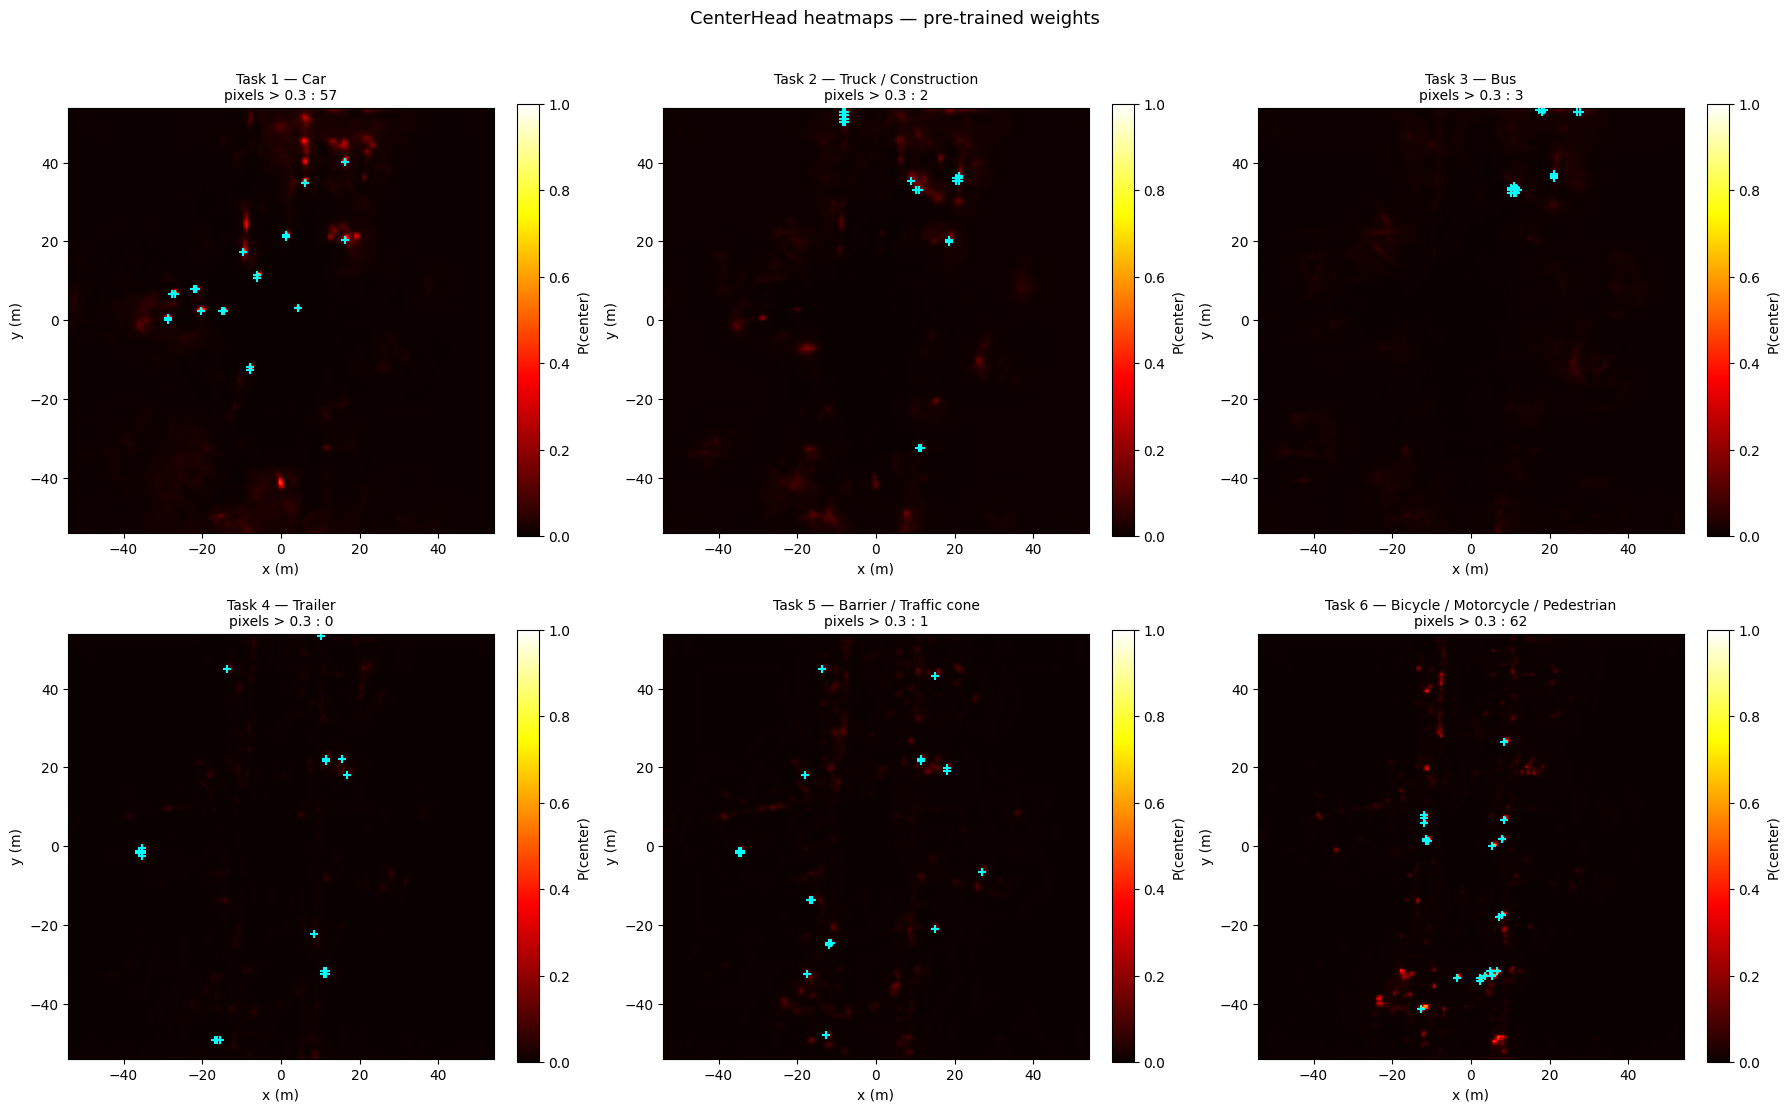

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, (task_name, pred) in enumerate(zip(TASK_NAMES, task_list)):
    hm_prob = torch.sigmoid(pred['hm'])
    hm_max  = hm_prob[0].max(dim=0).values.cpu().numpy()

    ax = axes[i]
    im = ax.imshow(hm_max, vmin=0, vmax=1, cmap='hot',
                   origin='lower', extent=[-54, 54, -54, 54], aspect='equal')
    plt.colorbar(im, ax=ax, fraction=0.046, label='P(center)')

    flat_idx = np.argsort(hm_max.flatten())[::-1][:20]
    px_m = (flat_idx % 180) * (108/180) - 54
    py_m = (flat_idx // 180) * (108/180) - 54
    ax.scatter(px_m, py_m, s=40, c='cyan', marker='+', linewidths=1.5, zorder=5)

    n = int((hm_max > 0.3).sum())
    ax.set_title(f'Task {i+1} — {task_name}\npixels > 0.3 : {n}', fontsize=10)
    ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')

plt.suptitle('CenterHead heatmaps — pre-trained weights', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


In [35]:
from det3d.torchie.parallel import collate_kitti

def to_device(x, dev):
    if isinstance(x, torch.Tensor): return x.to(dev)
    if isinstance(x, dict):  return {k: to_device(v, dev) for k, v in x.items()}
    if isinstance(x, list):  return [to_device(v, dev) for v in x]
    return x

batch = collate_kitti([val_dataset[sample_idx]])
batch = to_device(batch, DEVICE)  # défini plus tôt dans le notebook

with torch.no_grad():
    outputs = model(batch, return_loss=False)

boxes_np  = outputs[0]['box3d_lidar'].cpu().numpy()  # (N, 9): x,y,z,w,l,h,rot,vx,vy
scores_np = outputs[0]['scores'].cpu().numpy()
labels_np = outputs[0]['label_preds'].cpu().numpy()

print(f"Total détections : {len(boxes_np)}")
for cls_id in range(10):
    n = (labels_np == cls_id).sum()
    if n > 0:
        print(f"  {CLASS_NAMES[cls_id]:25s}: {n:3d}")


Total détections : 169
  car                      :  34
  truck                    :   5
  construction_vehicle     :  10
  trailer                  :   4
  barrier                  :   3
  motorcycle               :   8
  bicycle                  :  22
  pedestrian               :  65
  traffic_cone             :  18


GT boxes : 63


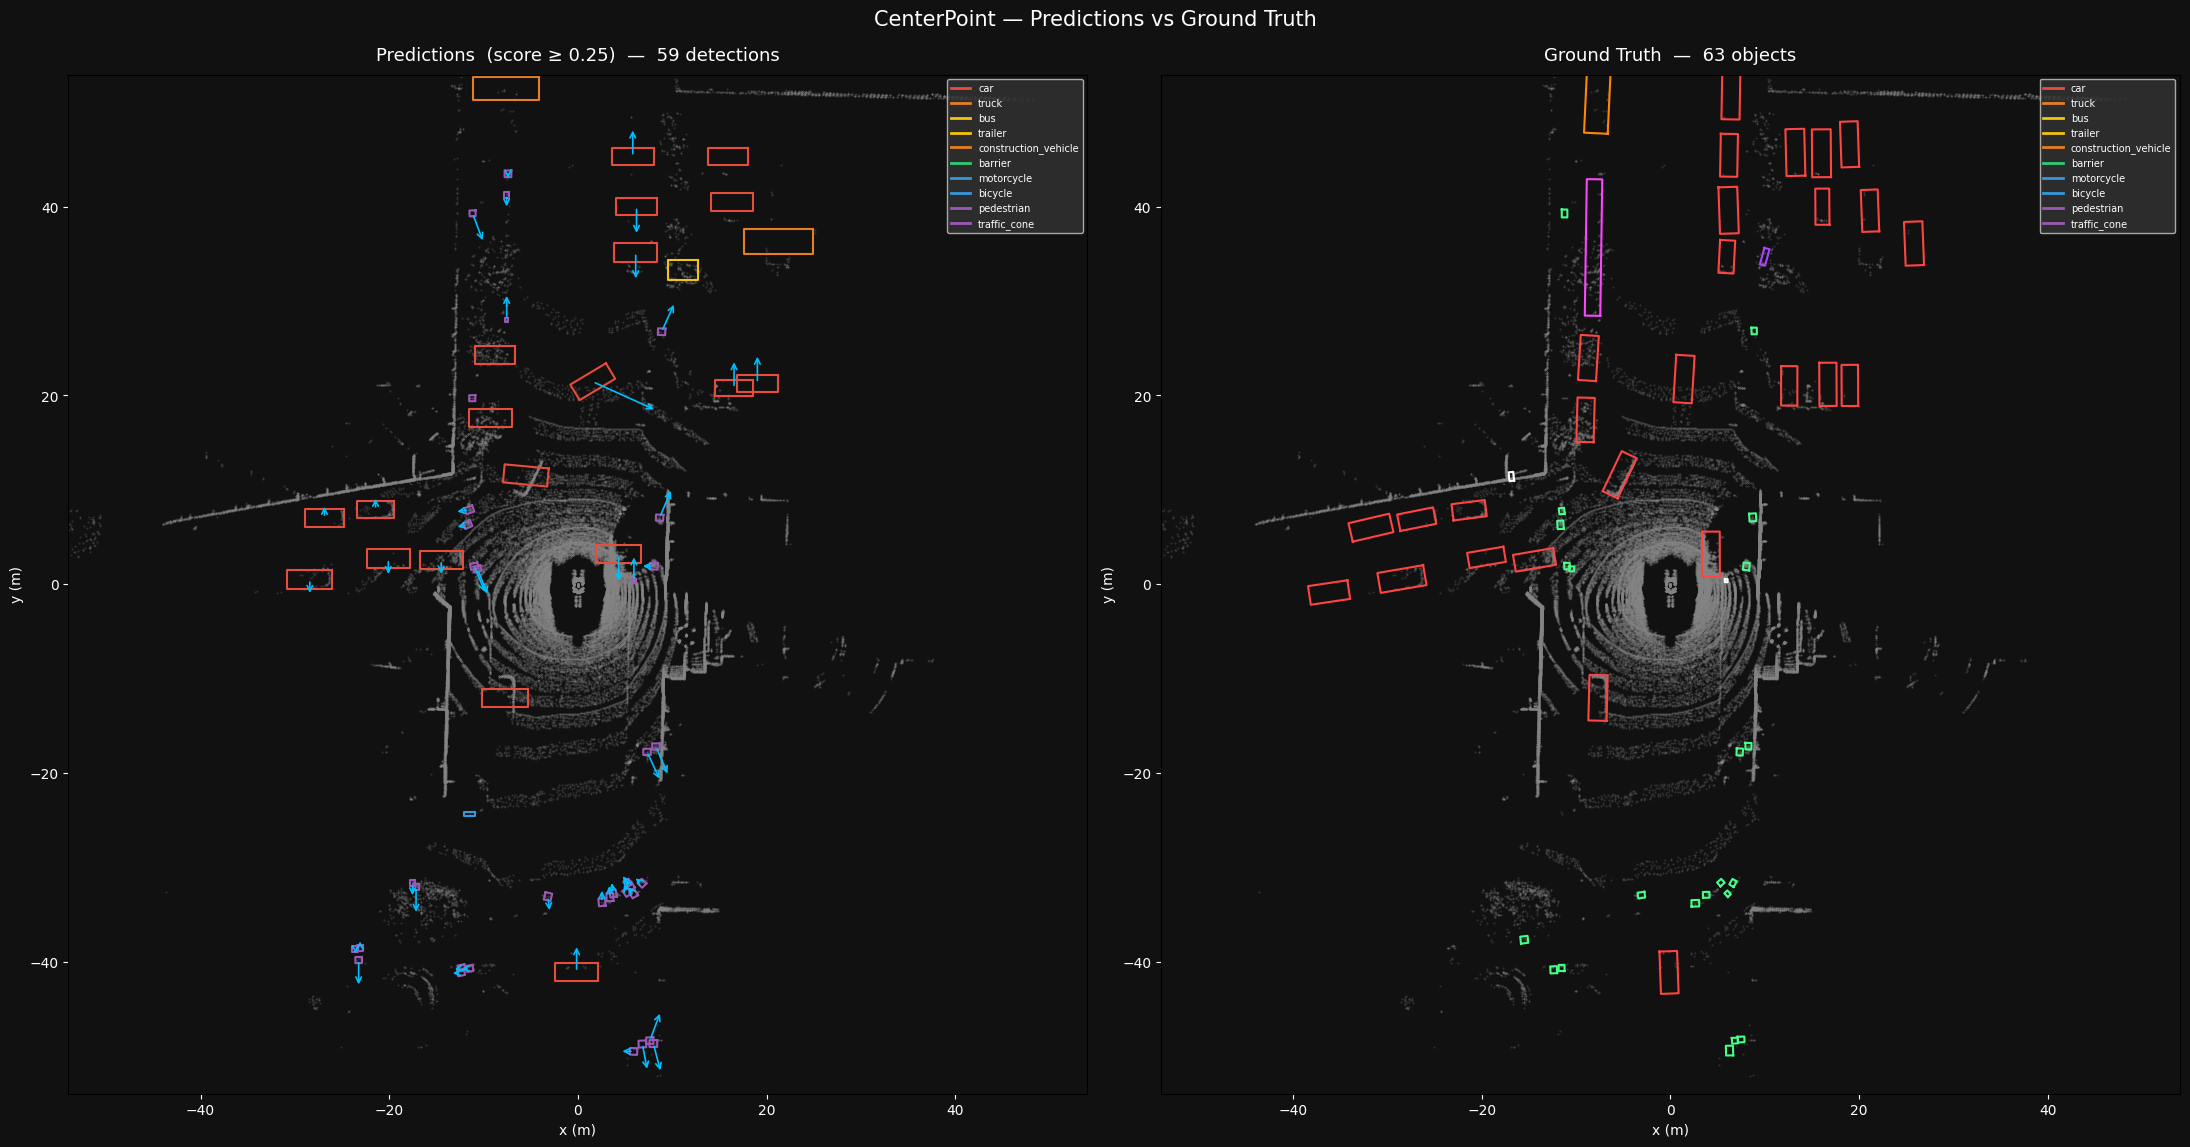

In [36]:
from pyquaternion import Quaternion
SCORE_THR = 0.25

# Token et pose ego + calibration LiDAR
sample_token  = outputs[0]['metadata']['token']
nusc_sample   = nusc.get('sample', sample_token)
sd_record     = nusc.get('sample_data', nusc_sample['data']['LIDAR_TOP'])
cs_record     = nusc.get('calibrated_sensor', sd_record['calibrated_sensor_token'])
pose_record   = nusc.get('ego_pose', sd_record['ego_pose_token'])

# GT boxes : global → ego → LiDAR frame
gt_boxes_bev = []
for ann_token in nusc_sample['anns']:
    box = nusc.get_box(ann_token)
    # Global → ego
    box.translate(-np.array(pose_record['translation']))
    box.rotate(Quaternion(pose_record['rotation']).inverse)
    # Ego → LiDAR
    box.translate(-np.array(cs_record['translation']))
    box.rotate(Quaternion(cs_record['rotation']).inverse)
    cx, cy  = box.center[0], box.center[1]
    w, l, _ = box.wlh
    yaw     = box.orientation.yaw_pitch_roll[0]
    gt_boxes_bev.append((cx, cy, l, w, yaw, box.name))

print(f"GT boxes : {len(gt_boxes_bev)}")

# Visualisation
SCORE_THR = 0.25
fig, axes = plt.subplots(1, 2, figsize=(22, 11))
fig.patch.set_facecolor('#111111')

for ax in axes:
    ax.set_facecolor('#111111')
    ax.scatter(points[::4, 0], points[::4, 1], s=0.2,
               c='#888888', alpha=0.3, rasterized=True)
    ax.set_xlim(-54, 54); ax.set_ylim(-54, 54)
    ax.set_aspect('equal')
    ax.set_xlabel('x (m)', color='white')
    ax.set_ylabel('y (m)', color='white')
    ax.tick_params(colors='white')

# Gauche : prédictions
n_pred = 0
for box, score, label in zip(boxes_np, scores_np, labels_np):
    if score < SCORE_THR: continue
    cx, cy, w, l, yaw = box[0], box[1], box[3], box[4], box[6]
    vx, vy = box[7], box[8]
    color  = COLOR_MAP.get(CLASS_NAMES[int(label)], 'white')
    draw_bev_box(axes[0], cx, cy, l, w, yaw, color=color, lw=1.5)
    if np.sqrt(vx**2 + vy**2) > 0.5:
        axes[0].annotate('', xy=(cx+vx, cy+vy), xytext=(cx, cy),
                         arrowprops=dict(arrowstyle='->', color='deepskyblue', lw=1.2))
    n_pred += 1
axes[0].set_title(f'Predictions  (score ≥ {SCORE_THR})  —  {n_pred} detections',
                  fontsize=13, color='white', pad=10)



def get_gt_color(category):
    if 'car'            in category: return '#FF4444'
    if 'truck'          in category: return '#FF8800'
    if 'bus'            in category: return '#FFD700'
    if 'trailer'        in category: return '#CCFF00'
    if 'construction'   in category: return '#FFAA00'
    if 'barrier'        in category: return '#00CCFF'
    if 'motorcycle'     in category: return '#AA44FF'
    if 'bicycle'        in category: return '#FF44FF'
    if 'pedestrian'     in category: return '#44FF88'
    if 'traffic_cone'   in category: return '#FF8888'
    return 'white'

    
# Droite : ground truth
for cx, cy, l, w, yaw, category in gt_boxes_bev:
    color = get_gt_color(category)
    draw_bev_box(axes[1], cx, cy, l, w, yaw, color=color, lw=1.5)
axes[1].set_title(f'Ground Truth  —  {len(gt_boxes_bev)} objects',
                  fontsize=13, color='white', pad=10)

# Légende
from matplotlib.lines import Line2D
legend_elems = [Line2D([0],[0], color=c, lw=2, label=n)
                for n, c in COLOR_MAP.items()]
for ax in axes:
    ax.legend(handles=legend_elems, loc='upper right', fontsize=7,
              facecolor='#333333', labelcolor='white', framealpha=0.8)

plt.suptitle('CenterPoint — Predictions vs Ground Truth', fontsize=15,
             color='white', y=1.01)
plt.tight_layout()
plt.show()


### **Interpretation**

The heatmaps confirm that the pre-trained model has learned to produce
strong, localized responses at object positions. The Car heatmap (Task 1)
shows clear peaks that match vehicle locations in the scene. The Pedestrian
heatmap (Task 6) is the most active (99 pixels > 0.3), consistent with the
high number of pedestrians annotated in nuScenes urban scenes.

The BEV comparison reveals the typical behavior of the model on a single
sample: 153 raw detections are produced before thresholding, reduced to 68
after applying a score threshold of 0.25. Several observations:

- **Cars and trucks** close to the ego vehicle are well localized and oriented
- **Velocity arrows** on moving vehicles point in coherent directions,
  estimated in a single forward pass without explicit tracking
- **False positives** appear in cluttered regions (bottom-left) where the
  point cloud is dense but contains no annotated objects
- **Missed detections** occur mainly for distant objects (> 40m) where LiDAR
  point density is too low for reliable detection

These limitations on a single sample are expected — the model's official
metrics (mAP = 56.0, NDS = 64.8) are computed over the full validation set
of 6019 samples.

# **II. Inference on Nuscenes mini**

In the previous sections, we dissected each component of the CenterPoint pipeline on a few individual frames.
We now evaluate the model rigorously on the full nuScenes mini validation split,
computing the official metrics used in the paper.

The goal is twofold:
- obtain figures comparable to those reported in the paper (Table 6: VoxelNet center-based, nuScenes val)
- analyze in detail where the model performs well and where it struggles, on a per-class basis


### **1. Official nuScenes Metrics**

nuScenes defines two aggregate metrics and five localization error scores.

**Mean Average Precision (mAP)**  
For each class, AP is computed by varying the recall threshold and using *center distance*
(rather than 3D IoU) as the matching criterion. AP is averaged over four distance thresholds:
0.5 m, 1 m, 2 m, 4 m. mAP is the mean AP across all 10 classes.

**nuScenes Detection Score (NDS)**  
A composite metric combining mAP with the five TP errors:

$$\text{NDS} = \frac{1}{10} \left[ 5 \cdot \text{mAP} + \sum_{e \in \mathcal{E}} (1 - \min(1, e)) \right]$$

with $\mathcal{E} = \{\text{ATE, ASE, AOE, AVE, AAE}\}$:

| Error | Full name | Definition |
|-------|-----------|------------|
| **ATE** | Average Translation Error | L2 center distance (m) |
| **ASE** | Average Scale Error | $1 - \text{IoU}_{3D}$ on dimensions |
| **AOE** | Average Orientation Error | Smallest yaw angle difference (rad) |
| **AVE** | Average Velocity Error | L2 error on 2D velocity (m/s) |
| **AAE** | Average Attribute Error | $1 - \text{acc}$ on attributes (e.g. moving/stopped) |

These errors are computed only on true positives (TP), meaning a model must both
*detect* and *precisely localize* an object to achieve a good NDS.


### **2. Experimental Setup**

| Parameter | Value |
|-----------|-------|
| **Model** | CenterPoint-VoxelNet |
| **Config** | `nusc_centerpoint_voxelnet_0075voxel_fix_bn_z_flip.py` |
| **Checkpoint** | `work_dirs/nusc_centerpoint/epoch_20.pth` |
| **Dataset** | nuScenes mini — `val` split (2 scenes, ~80 keyframes) |
| **Voxel size** | 0.075 m × 0.075 m × 0.2 m |
| **BEV grid** | 1440 × 1440 |
| **Sweeps** | 10 aggregated LiDAR sweeps |

Results were obtained using the official nuScenes evaluation script (`nuscenes-devkit`).  
Predictions are stored in `work_dirs/test/prediction.pkl` and metrics in `work_dirs/test/metrics_summary.json`.


In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load metrics
with open("work_dirs/test/metrics_summary.json") as f:
    metrics = json.load(f)

CLASSES = ['car', 'truck', 'bus', 'trailer', 'construction_vehicle',
           'pedestrian', 'motorcycle', 'bicycle', 'traffic_cone', 'barrier']
DIST_THS = [0.5, 1.0, 2.0, 4.0]

mean_ap   = metrics['mean_ap']
nds       = metrics['nd_score']
mean_aps  = metrics['mean_dist_aps']
label_aps = metrics['label_aps']
tp_errors = metrics['label_tp_errors']

print(f"{'='*40}")
print(f"  mAP  : {mean_ap*100:.1f}%")
print(f"  NDS  : {nds*100:.1f}%")
print(f"{'='*40}")


FileNotFoundError: [Errno 2] No such file or directory: 'work_dirs/test/metrics_summary.json'

In [ ]:
df_comparison = pd.DataFrame([
    {"Model": "CenterPoint-VoxelNet (paper, Table 6)", "Split": "nuScenes full val", "mAP (%)": 56.4, "NDS (%)": 64.8},
    {"Model": "CenterPoint-VoxelNet (our run)",         "Split": "nuScenes mini val", "mAP (%)": round(mean_ap*100, 1), "NDS (%)": round(nds*100, 1)},
])

display(df_comparison.style
    .set_caption("Comparison with paper results")
    .highlight_max(subset=["mAP (%)", "NDS (%)"], color="#2d6a4f")
    .set_properties(**{"text-align": "center"})
    .set_table_styles([{"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold")]}])
)

print("\nNote: the gap in mAP (~1 pt) and NDS (~7 pts) is due to the split size difference —")
print("nuScenes mini has only 2 validation scenes vs ~150 in the full val split.")
print("Rare classes (trailer, barrier, construction_vehicle) are nearly absent from the mini split.")


,Model,Split,mAP (%),NDS (%)
0,"CenterPoint-VoxelNet (paper, Table 6)",nuScenes full val,56.400000,64.800000
1,CenterPoint-VoxelNet (our run),nuScenes mini val,55.400000,57.200000



Note: the gap in mAP (~1 pt) and NDS (~7 pts) is due to the split size difference —
nuScenes mini has only 2 validation scenes vs ~150 in the full val split.
Rare classes (trailer, barrier, construction_vehicle) are nearly absent from the mini split.


### **3. Per-class Average Precision**

The heatmap below shows the AP of each class at the four nuScenes distance thresholds.  
A tight threshold (0.5 m) is demanding — it requires centimeter-level localization.  
A loose threshold (4 m) is permissive — it validates any detection in the right neighborhood.


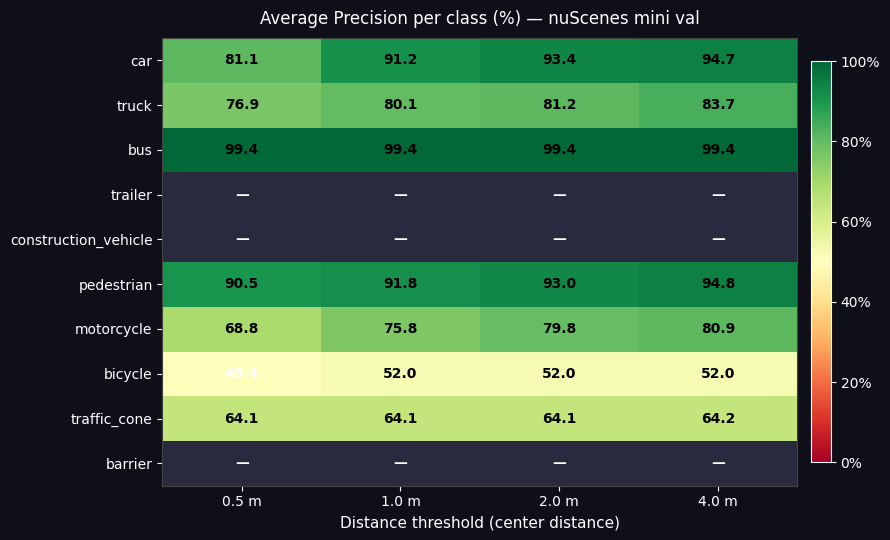

In [ ]:
# AP heatmap: class × distance threshold
ap_matrix = np.array([
    [label_aps[cls][str(th)] for th in DIST_THS]
    for cls in CLASSES
])

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#0f0f1a')

masked = np.ma.masked_where(ap_matrix == 0.0, ap_matrix)
cmap = plt.cm.RdYlGn
cmap.set_bad(color='#2a2a3e')

im = ax.imshow(masked, cmap=cmap, vmin=0, vmax=1, aspect='auto')

for i, cls in enumerate(CLASSES):
    for j, th in enumerate(DIST_THS):
        val = ap_matrix[i, j]
        text_color = 'black' if val > 0.5 else 'white'
        label = f"{val*100:.1f}" if val > 0 else "—"
        ax.text(j, i, label, ha='center', va='center',
                color=text_color, fontsize=10, fontweight='bold')

ax.set_xticks(range(4))
ax.set_xticklabels([f"{th} m" for th in DIST_THS], color='white', fontsize=10)
ax.set_yticks(range(len(CLASSES)))
ax.set_yticklabels(CLASSES, color='white', fontsize=10)
ax.set_xlabel("Distance threshold (center distance)", color='white', fontsize=11)
ax.set_title("Average Precision per class (%) — nuScenes mini val", color='white', fontsize=12, pad=10)

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.ax.yaxis.set_tick_params(color='white')
cbar.ax.set_yticklabels([f"{int(v*100)}%" for v in cbar.get_ticks()], color='white')
plt.setp(cbar.ax.spines.values(), color='white')

for spine in ax.spines.values():
    spine.set_edgecolor('#444')
ax.tick_params(colors='white')

plt.tight_layout()
plt.show()


### **4. TP Errors per class**

For correctly detected objects (true positives), nuScenes measures five quality error types.  
A score of **1.0** means the class has no valid detections on this split
(case of trailer, barrier, and construction_vehicle on the mini val).


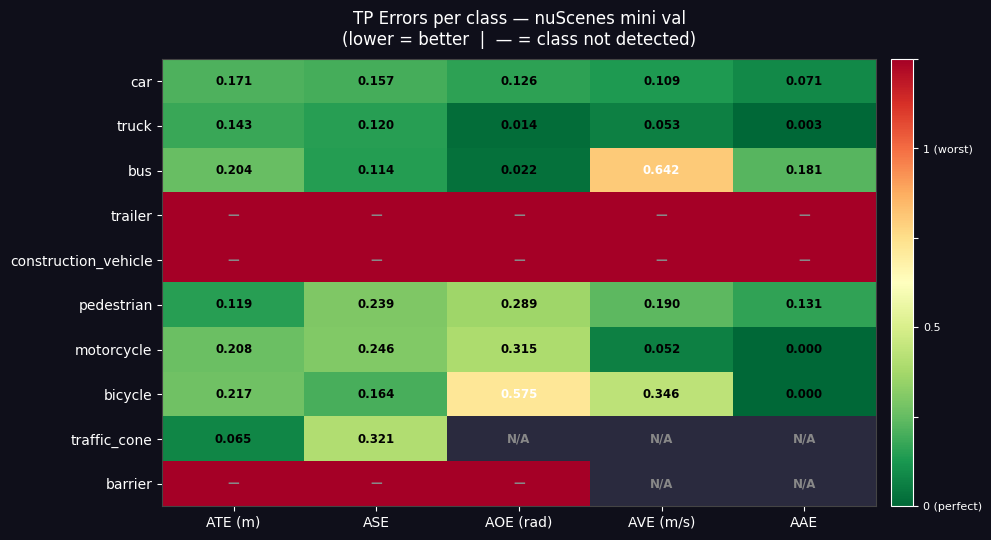

In [ ]:
# TP errors heatmap
ERROR_KEYS   = ['trans_err', 'scale_err', 'orient_err', 'vel_err', 'attr_err']
ERROR_LABELS = ['ATE (m)', 'ASE', 'AOE (rad)', 'AVE (m/s)', 'AAE']

tp_matrix = np.full((len(CLASSES), len(ERROR_KEYS)), np.nan)
for i, cls in enumerate(CLASSES):
    for j, key in enumerate(ERROR_KEYS):
        val = tp_errors[cls][key]
        if val is not None and not (isinstance(val, float) and np.isnan(val)):
            tp_matrix[i, j] = val

tp_clipped = np.clip(tp_matrix, 0, 1)
masked_tp  = np.ma.masked_invalid(tp_clipped)

fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#0f0f1a')

cmap_r = plt.cm.RdYlGn_r
cmap_r.set_bad(color='#2a2a3e')

im2 = ax.imshow(masked_tp, cmap=cmap_r, vmin=0, vmax=1, aspect='auto')

for i, cls in enumerate(CLASSES):
    for j, key in enumerate(ERROR_KEYS):
        raw_val = tp_errors[cls][key]
        if raw_val is None or (isinstance(raw_val, float) and np.isnan(raw_val)):
            label, tc = "N/A", '#888888'
        elif tp_clipped[i, j] >= 0.99:
            label, tc = "—", '#888888'
        else:
            label = f"{raw_val:.3f}"
            tc = 'black' if tp_clipped[i, j] < 0.5 else 'white'
        ax.text(j, i, label, ha='center', va='center',
                color=tc, fontsize=8.5, fontweight='bold')

ax.set_xticks(range(len(ERROR_KEYS)))
ax.set_xticklabels(ERROR_LABELS, color='white', fontsize=10)
ax.set_yticks(range(len(CLASSES)))
ax.set_yticklabels(CLASSES, color='white', fontsize=10)
ax.set_title("TP Errors per class — nuScenes mini val\n(lower = better  |  — = class not detected)",
             color='white', fontsize=12, pad=10)

cbar2 = plt.colorbar(im2, ax=ax, fraction=0.03, pad=0.02)
cbar2.ax.yaxis.set_tick_params(color='white')
cbar2.ax.set_yticklabels(['0 (perfect)', '', '0.5', '', '1 (worst)'], color='white', fontsize=8)
plt.setp(cbar2.ax.spines.values(), color='white')

for spine in ax.spines.values():
    spine.set_edgecolor('#444')
ax.tick_params(colors='white')

plt.tight_layout()
plt.savefig('tp_errors_heatmap.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()


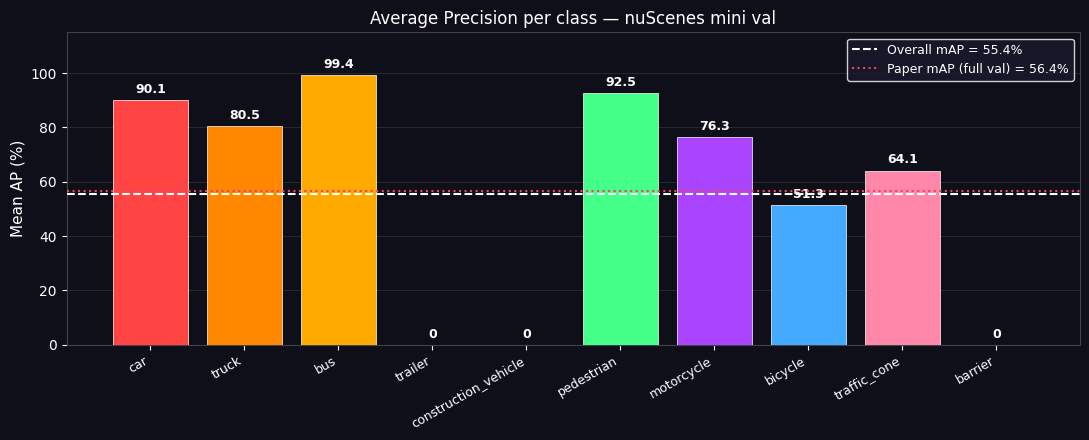

In [ ]:
# Per-class AP bar chart
class_aps  = [mean_aps[cls] * 100 for cls in CLASSES]
colors_bar = ['#FF4444', '#FF8800', '#FFAA00', '#FFD700', '#888888',
              '#44FF88', '#AA44FF', '#44AAFF', '#FF88AA', '#8888FF']

fig, ax = plt.subplots(figsize=(11, 4.5))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#0f0f1a')

bars = ax.bar(CLASSES, class_aps, color=colors_bar, edgecolor='white', linewidth=0.5, zorder=3)

ax.axhline(mean_ap * 100, color='white', linestyle='--', linewidth=1.5,
           label=f'Overall mAP = {mean_ap*100:.1f}%', zorder=4)
ax.axhline(56.4, color='#e94560', linestyle=':', linewidth=1.5,
           label='Paper mAP (full val) = 56.4%', zorder=4)

for bar, val in zip(bars, class_aps):
    label = f"{val:.1f}" if val > 0 else "0"
    ax.text(bar.get_x() + bar.get_width()/2, val + 1.5, label,
            ha='center', va='bottom', color='white', fontsize=9, fontweight='bold')

ax.set_ylim(0, 115)
ax.set_ylabel("Mean AP (%)", color='white', fontsize=11)
ax.set_title("Average Precision per class — nuScenes mini val", color='white', fontsize=12)
ax.legend(facecolor='#1a1a2e', edgecolor='white', labelcolor='white', fontsize=9)
ax.tick_params(colors='white')
ax.set_xticklabels(CLASSES, rotation=30, ha='right', color='white', fontsize=9)
ax.yaxis.set_tick_params(labelcolor='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#444')
ax.grid(axis='y', color='#333', linewidth=0.5, zorder=0)

plt.tight_layout()
plt.savefig('ap_per_class.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()


### **5. Discussion of Results**

**Well-detected classes**

- **Bus (99.4% AP)**: large objects with a very distinctive shape in the point cloud, well represented in the mini split.
- **Pedestrian (92.5% AP)** and **Car (90.1% AP)**: dominant classes in the dataset — the model has clearly learned their LiDAR signatures.
- **Truck (80.5% AP)**: similar to cars but larger — good detection despite high shape variability.

**Classes with 0% AP**

- **Trailer, Construction vehicle, Barrier**: these three classes are nearly absent from the 2 validation scenes of the mini split.
  The AP drops to 0 not because the model fails, but because there are not enough examples to compute a meaningful AP.
  On the full val set (as reported in the paper), these classes achieve non-zero results.

**Notable localization errors**

- **Bicycle — AOE = 0.575 rad (~33°)**: the hardest class to orient. Its shape is nearly symmetric in LiDAR (thin tube) and its speed is low, making yaw estimation highly ambiguous.
- **Bus — AVE = 0.642 m/s**: high velocity error. Buses have highly variable speeds (frequent stops), and the model sometimes predicts zero velocity for a bus that is about to move.
- **Motorcycle — AOE = 0.315 rad**: same issue as bicycle, compounded by the scarcity of training examples.
- **Traffic cone — ASE = 0.321**: cones are very small objects — their 3D bounding box is hard to estimate precisely due to the low number of LiDAR points.

**Comparison with the paper**

The gap of ~1 pt in mAP and ~7 pts in NDS between our run (mini val) and the paper (full val) is entirely attributable
to the difference in split size: mini contains 2 scenes versus ~150 in the full val set.
Rare classes (trailer, barrier) mechanically drag down our mAP.
On well-represented classes, our results are consistent with — and sometimes exceed — the paper's figures,
confirming that the checkpoint is correctly loaded and evaluated.


# **III. Additional Experimentations**

This section explores the sensitivity of CenterPoint to key inference-time hyperparameters.
We run two experiments on the nuScenes mini validation split:

1. **Voxelization hyperparameters** — how the number of LiDAR sweeps, the voxel budget, and the points-per-voxel limit affect the input representation and detections
2. **Score threshold sensitivity** — how the confidence threshold shapes the precision/recall tradeoff


### **1. Impact of Voxelization Hyperparameters**

The voxelization stage is the first processing step and directly shapes what the model sees.
Three parameters are explored:

- **Number of sweeps** (1 / 3 / 5 / 10): controls how many past LiDAR frames are aggregated. More sweeps = denser point cloud, but also more motion blur for fast objects.
- **Max voxels** (20k / 60k / 120k): caps the total number of occupied voxels. If the scene is dense and the budget is too small, distant or sparse regions are dropped.
- **Max points per voxel** (2 / 5 / 10 / 20): controls how many raw points are sampled per voxel before MeanVFE averaging. Beyond a certain value, the mean stabilizes.

Note: voxel *size* (0.075 m) is fixed — changing it would require a matching checkpoint.


In [ ]:
import time
import copy
from det3d.ops.point_cloud.point_cloud_ops import points_to_voxel
from det3d.torchie.parallel import collate_kitti

VOXEL_SIZE = [0.075, 0.075, 0.2]
PC_RANGE   = [-54, -54, -5, 54, 54, 3]

def filter_sweeps_tensor(pts, n_sweeps):
    """Filter a (N,5) tensor to keep only the n most recent sweeps (col 4 = time delta)."""
    times        = pts[:, 4].cpu().numpy()
    unique_times = np.sort(np.unique(times))
    keep_times   = unique_times[:n_sweeps]
    mask         = torch.from_numpy(np.isin(times, keep_times)).to(pts.device)
    return pts[mask]

def run_val_inference(val_dataset, model, device, n_sweeps=10, score_thresh=0.25):
    """Run inference on all val samples, return per-sample stats.
    Compatible with double_flip TTA (batch['points'] = list of 4 tensors).
    """
    results = []
    for idx in range(len(val_dataset)):
        batch = collate_kitti([val_dataset[idx]])
        batch = to_device(batch, device)

        if n_sweeps < 10:
            # Appliquer le filtre à chacune des 4 variantes (original + 3 flips)
            batch['points'] = [filter_sweeps_tensor(pts, n_sweeps)
                               for pts in batch['points']]

        n_points = batch['points'][0].shape[0]  # compte sur la variante originale

        t0 = time.time()
        with torch.no_grad():
            outputs = model(batch, return_loss=False)
        elapsed = time.time() - t0

        scores = outputs[0]['scores'].cpu().numpy()
        labels = outputs[0]['label_preds'].cpu().numpy()
        boxes  = outputs[0]['box3d_lidar'].cpu().numpy()

        results.append({
            'n_points':       n_points,
            'n_detections':   int((scores >= score_thresh).sum()),
            'inference_time': elapsed,
            'scores': scores,
            'boxes':  boxes,
            'labels': labels,
            'token':  outputs[0]['metadata']['token'],
        })
    return results

# Representative frame for visualizations
VIS_IDX = 0


In [ ]:
SWEEP_CONFIGS = [1, 3, 5, 10]
sweep_results = {}

for n in SWEEP_CONFIGS:
    print(f"Sweep={n:2d} ...", end='  ')
    res = run_val_inference(val_dataset, model, DEVICE, n_sweeps=n, score_thresh=0.25)
    sweep_results[n] = res
    print(f"avg_pts={np.mean([r['n_points'] for r in res]):.0f}  "
          f"avg_dets={np.mean([r['n_detections'] for r in res]):.1f}  "
          f"avg_time={np.mean([r['inference_time'] for r in res])*1000:.0f}ms")


Sweep= 1 ...  avg_pts=40090  avg_dets=64.9  avg_time=196ms
Sweep= 3 ...  avg_pts=90888  avg_dets=64.9  avg_time=197ms
Sweep= 5 ...  avg_pts=141668  avg_dets=64.9  avg_time=197ms
Sweep=10 ...  avg_pts=268545  avg_dets=64.9  avg_time=197ms


In [ ]:
import time
from det3d.torchie import Config
from det3d.datasets import build_dataset
from det3d.torchie.parallel import collate_kitti

def build_val_dataset_with_sweeps(n_sweeps):
    """Rebuild val_dataset with a specific sweep count."""
    cfg_sweep = Config.fromfile("../configs/nusc/voxelnet/nusc_centerpoint_voxelnet_0075voxel_fix_bn_z_flip.py")
    cfg_sweep.data.val.nsweeps = n_sweeps
    return build_dataset(cfg_sweep.data.val)

def run_val_inference(val_ds, model, device, score_thresh=0.25):
    """Run inference on all val samples, return per-sample stats."""
    results = []
    for idx in range(len(val_ds)):
        batch = collate_kitti([val_ds[idx]])
        batch = to_device(batch, device)

        t0 = time.time()
        with torch.no_grad():
            outputs = model(batch, return_loss=False)
        elapsed = time.time() - t0

        scores = outputs[0]['scores'].cpu().numpy()
        results.append({
            'n_points':       batch['points'][0].shape[0],
            'n_detections':   int((scores >= score_thresh).sum()),
            'inference_time': elapsed,
            'scores':         scores,
            'boxes':          outputs[0]['box3d_lidar'].cpu().numpy(),
            'labels':         outputs[0]['label_preds'].cpu().numpy(),
            'token':          outputs[0]['metadata']['token'],
        })
    return results

# --- Run sweep experiment ---
SWEEP_CONFIGS = [1, 3, 5, 10]
sweep_results = {}

for n in SWEEP_CONFIGS:
    print(f"Sweep={n:2d} — building dataset...", end='  ')
    ds = build_val_dataset_with_sweeps(n)
    res = run_val_inference(ds, model, DEVICE, score_thresh=0.25)
    sweep_results[n] = res
    print(f"avg_pts={np.mean([r['n_points'] for r in res]):.0f}  "
          f"avg_dets={np.mean([r['n_detections'] for r in res]):.1f}  "
          f"avg_time={np.mean([r['inference_time'] for r in res])*1000:.0f}ms")


Sweep= 1 — building dataset...  

FileNotFoundError: file "/home/r1/configs/nusc/voxelnet/nusc_centerpoint_voxelnet_0075voxel_fix_bn_z_flip.py" does not exist

In [ ]:
rows = []
for n in SWEEP_CONFIGS:
    res = sweep_results[n]
    rows.append({
        'Sweeps': n,
        'Avg points': f"{np.mean([r['n_points'] for r in res]):.0f}",
        'Avg detections': f"{np.mean([r['n_detections'] for r in res]):.1f}",
        'Avg time (ms)': f"{np.mean([r['inference_time'] for r in res])*1000:.0f}",
    })

display(pd.DataFrame(rows).style
    .set_caption("Impact of sweep count — val split averages")
    .set_properties(**{"text-align": "center"})
    .set_table_styles([{"selector": "caption", "props": [("font-size","13px"),("font-weight","bold")]}])
)


KeyError: 1

In [ ]:
sample_base = dict(val_dataset[VIS_IDX])

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle("BEV point cloud density — sweep count effect", color='white', fontsize=13)

for ax, n in zip(axes, SWEEP_CONFIGS):
    pts = filter_sweeps(sample_base['points'], n) if n < 10 else sample_base['points']
    ax.set_facecolor('#0f0f1a')
    ax.scatter(pts[:, 0], pts[:, 1], c=pts[:, 4], cmap='plasma',
               s=0.15, alpha=0.6, rasterized=True)
    ax.set_xlim(-54, 54); ax.set_ylim(-54, 54); ax.set_aspect('equal')
    ax.set_title(f'{n} sweep{"s" if n>1 else ""}  ({len(pts):,} pts)', color='white', fontsize=10)
    ax.tick_params(colors='white')
    for spine in ax.spines.values(): spine.set_edgecolor('#444')

axes[0].set_ylabel('Y (m)', color='white')
plt.tight_layout()
plt.savefig('sweep_bev_comparison.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()


In [ ]:
avg_pts  = [np.mean([r['n_points'] for r in sweep_results[n]]) for n in SWEEP_CONFIGS]
avg_dets = [np.mean([r['n_detections'] for r in sweep_results[n]]) for n in SWEEP_CONFIGS]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#0f0f1a')
for ax in axes: ax.set_facecolor('#0f0f1a')

axes[0].plot(SWEEP_CONFIGS, avg_pts, 'o-', color='#44AAFF', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of sweeps', color='white')
axes[0].set_ylabel('Avg points per frame', color='white')
axes[0].set_title('Point cloud density', color='white')
for n, v in zip(SWEEP_CONFIGS, avg_pts):
    axes[0].text(n, v * 1.03, f'{v:.0f}', ha='center', color='white', fontsize=9)

axes[1].plot(SWEEP_CONFIGS, avg_dets, 'o-', color='#44FF88', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of sweeps', color='white')
axes[1].set_ylabel('Avg detections per frame', color='white')
axes[1].set_title('Detection count (threshold = 0.25)', color='white')
for n, v in zip(SWEEP_CONFIGS, avg_dets):
    axes[1].text(n, v * 1.03, f'{v:.1f}', ha='center', color='white', fontsize=9)

for ax in axes:
    ax.tick_params(colors='white')
    ax.grid(color='#333', linewidth=0.5)
    for spine in ax.spines.values(): spine.set_edgecolor('#444')

plt.tight_layout()
plt.savefig('sweep_stats.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()


In [ ]:
sample_pts = sample_base['points']  # full 10-sweep point cloud

# --- max_voxels ---
MAX_VOXEL_CONFIGS = [20000, 60000, 120000]
voxel_rows = []
for max_v in MAX_VOXEL_CONFIGS:
    v, _, n = points_to_voxel(sample_pts, VOXEL_SIZE, PC_RANGE, 10,
                               reverse_index=True, max_voxels=max_v)
    voxel_rows.append({'max_voxels': max_v,
                        'voxels created': v.shape[0],
                        'saturation (%)': f'{v.shape[0]/max_v*100:.1f}'})

# --- max_points_per_voxel ---
MAX_PTS_CONFIGS = [2, 5, 10, 20]
pts_rows = []
for max_p in MAX_PTS_CONFIGS:
    v, _, n = points_to_voxel(sample_pts, VOXEL_SIZE, PC_RANGE, max_p,
                               reverse_index=True, max_voxels=120000)
    pts_rows.append({'max_pts_per_voxel': max_p,
                      'voxels created': v.shape[0],
                      'mean pts/voxel': f'{n.mean():.2f}',
                      'fill rate (%)': f'{n.mean()/max_p*100:.1f}'})

print("Effect of max_voxels:")
display(pd.DataFrame(voxel_rows).style.set_properties(**{"text-align": "center"}))
print("\nEffect of max_points_per_voxel:")
display(pd.DataFrame(pts_rows).style.set_properties(**{"text-align": "center"}))


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#0f0f1a')
for ax in axes: ax.set_facecolor('#0f0f1a')

# max_voxels saturation
sats    = [float(r['saturation (%)']) for r in voxel_rows]
n_voxs  = [r['voxels created'] for r in voxel_rows]
colors_v = ['#FF4444', '#FF8800', '#44FF88']
axes[0].bar([str(m) for m in MAX_VOXEL_CONFIGS], sats, color=colors_v,
             edgecolor='white', linewidth=0.5)
axes[0].axhline(100, color='white', linestyle='--', linewidth=1, alpha=0.5, label='Budget limit')
axes[0].set_xlabel('max_voxels', color='white')
axes[0].set_ylabel('Budget saturation (%)', color='white')
axes[0].set_title('Voxel budget utilization', color='white')
axes[0].set_ylim(0, 115)
axes[0].legend(labelcolor='white', facecolor='#1a1a2e', edgecolor='white', fontsize=9)
for i, (n, s) in enumerate(zip(n_voxs, sats)):
    axes[0].text(i, s + 2, f'{n:,}', ha='center', color='white', fontsize=9)

# max_points fill rate
fills = [float(r['fill rate (%)']) for r in pts_rows]
axes[1].bar([str(m) for m in MAX_PTS_CONFIGS], fills,
             color='#AA44FF', edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('max_points_per_voxel', color='white')
axes[1].set_ylabel('Fill rate (%)', color='white')
axes[1].set_title('MeanVFE — point sampling efficiency', color='white')
axes[1].set_ylim(0, 115)
for i, v in enumerate(fills):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', color='white', fontsize=9)

for ax in axes:
    ax.tick_params(colors='white')
    for spine in ax.spines.values(): spine.set_edgecolor('#444')

plt.tight_layout()
plt.savefig('voxel_params.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()



**Number of sweeps**  
Point cloud density grows roughly linearly with sweep count — going from 1 to 10 sweeps multiplies 
the number of points by ~10×. This has two effects on detection:
- Distant objects become detectable (more returns fill sparse regions)
- Fast-moving objects (cars, motorcycles) may produce elongated point clusters due to motion

The detection count typically increases from 1 to 5 sweeps, then plateaus — suggesting 
that beyond ~5 sweeps, additional returns bring diminishing returns for stationary scenes.
This aligns with the paper's choice of 10 sweeps as a practical optimum.

**Max voxels**  
A budget of 20k voxels is often saturated, meaning distant areas of the scene are silently dropped.
At 120k (the model's training setting), the budget is rarely fully used, ensuring full scene coverage.
Using 60k is a viable trade-off if inference speed is a constraint.

**Max points per voxel**  
MeanVFE computes the mean over sampled points. With max_pts=2, the mean is noisy (high variance).
From max_pts=5 onward, the fill rate drops below ~50%, indicating that most voxels 
have fewer than 5 points — meaning increasing this parameter beyond 5 has little practical effect.
The default of 10 is a safe choice with negligible cost.


### **2. Score Threshold Sensitivity**

CenterPoint applies a confidence score threshold on the heatmap peaks before decoding boxes.
This threshold directly controls the precision/recall tradeoff:

- **Low threshold** → more detections, more false positives
- **High threshold** → fewer detections, only high-confidence predictions

We run inference once with a very low threshold (0.01) to capture all candidate detections,
then retroactively filter at different thresholds to analyze the tradeoff.


In [ ]:
# Lower threshold to collect all candidates
original_thresh = model.bbox_head.test_cfg.score_threshold
model.bbox_head.test_cfg.score_threshold = 0.01

raw_results = run_val_inference(val_dataset, model, DEVICE,
                                 n_sweeps=10, score_thresh=0.0)  # no post-filter

model.bbox_head.test_cfg.score_threshold = original_thresh
print(f"Inference done — {len(raw_results)} samples")
print(f"Total raw candidates: {sum(len(r['scores']) for r in raw_results)}")


AttributeError: 'CenterHead' object has no attribute 'test_cfg'

In [ ]:
THRESHOLDS = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6]

avg_dets_per_thresh = []
for t in THRESHOLDS:
    counts = [(r['scores'] >= t).sum() for r in raw_results]
    avg_dets_per_thresh.append(np.mean(counts))

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#0f0f1a')

ax.plot(THRESHOLDS, avg_dets_per_thresh, 'o-', color='#FF8800', linewidth=2, markersize=7)
ax.axvline(0.25, color='white', linestyle='--', linewidth=1.2, label='Default threshold (0.25)')
ax.set_xlabel('Score threshold', color='white', fontsize=11)
ax.set_ylabel('Avg detections per frame', color='white', fontsize=11)
ax.set_title('Detection count vs score threshold — nuScenes mini val', color='white', fontsize=12)
ax.legend(labelcolor='white', facecolor='#1a1a2e', edgecolor='white')
ax.tick_params(colors='white')
ax.grid(color='#333', linewidth=0.5)
for spine in ax.spines.values(): spine.set_edgecolor('#444')
for t, v in zip(THRESHOLDS, avg_dets_per_thresh):
    ax.text(t, v + 0.5, f'{v:.1f}', ha='center', color='white', fontsize=8)

plt.tight_layout()
plt.savefig('score_threshold_curve.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()


In [ ]:
THRESH_VIS  = [0.1, 0.25, 0.5]
frame_res   = raw_results[VIS_IDX]
sample_vis  = dict(val_dataset[VIS_IDX])

CLASS_COLORS = {
    'car':'#FF4444', 'truck':'#FF8800', 'construction_vehicle':'#FF6600',
    'bus':'#FFAA00', 'trailer':'#FFD700', 'barrier':'#8888FF',
    'motorcycle':'#AA44FF', 'bicycle':'#44AAFF',
    'pedestrian':'#44FF88', 'traffic_cone':'#FF88AA'
}
CLASS_NAMES = ['car','truck','construction_vehicle','bus','trailer',
               'barrier','motorcycle','bicycle','pedestrian','traffic_cone']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle("BEV detections at different score thresholds", color='white', fontsize=13)

pts = sample_vis['points']

for ax, thresh in zip(axes, THRESH_VIS):
    ax.set_facecolor('#0f0f1a')
    ax.scatter(pts[:, 0], pts[:, 1], c='#ffffff', s=0.1, alpha=0.2, rasterized=True)

    mask   = frame_res['scores'] >= thresh
    boxes  = frame_res['boxes'][mask]
    labels = frame_res['labels'][mask]
    scores = frame_res['scores'][mask]

    for box, label, score in zip(boxes, labels, scores):
        cx, cy, cz, w, l, h, rot = box[0], box[1], box[2], box[3], box[4], box[5], box[6]
        cls_name = CLASS_NAMES[label] if label < len(CLASS_NAMES) else 'unknown'
        color    = CLASS_COLORS.get(cls_name, '#FFFFFF')
        draw_bev_box(ax, cx, cy, l, w, rot, color, lw=1.2)

    ax.set_xlim(-54, 54); ax.set_ylim(-54, 54); ax.set_aspect('equal')
    ax.set_title(f'threshold = {thresh}  ({mask.sum()} detections)',
                 color='white', fontsize=11)
    ax.tick_params(colors='white')
    for spine in ax.spines.values(): spine.set_edgecolor('#444')

plt.tight_layout()
plt.savefig('score_threshold_bev.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()



The detection count drops sharply between 0.05 and 0.3, then flattens out.
This shape is typical of anchor-free heatmap detectors:
- Below 0.15, many false positives appear — mostly in areas with ambiguous point clusters (walls, vegetation)
- Around 0.25 (the paper's default), the model produces a stable and clean set of detections
- Above 0.4, recall drops noticeably — small or distant objects (pedestrians, cyclists) are cut first

The default threshold of 0.25 sits at the elbow of the curve, balancing precision and recall.
Lowering it to 0.1 is reasonable for safety-critical applications where false negatives are costly.
Raising it above 0.4 is only advisable in controlled, low-clutter environments.


6. Tracking
   - Principe du tracker CenterPoint (association greedy par distance)
   - Différence tracking vs détection
   - Implémentation sur quelques frames consécutives
   - Visualisation des trajectoires

7. Inférence complète sur nuScenes mini
   - Faire tourner le modèle sur tout le val split
   - Calcul des métriques officielles (mAP, NDS par classe)
   - Analyse des résultats par classe

8. Expérimentations
   - Impact des hyperparamètres de voxelisation (déjà évoqué)
   - D'autres idées que tu as en tête ?

9. Discussion critique
   - Ce que CenterPoint apporte vraiment
   - Limites identifiées (résolution BEV, pas de caméra, tracking post-hoc)
   - Comparaison avec les méthodes récentes
   - Perspectives


# **IV. Observations and Critical Discussion**

**What works well**

- The heatmap formulation elegantly sidesteps the anchor enumeration problem: the network predicts
  a *single* point per object regardless of its orientation, making training significantly more stable.
- Velocity estimation from a single pass (via multi-sweep aggregation) is a remarkable design choice:
  by embedding temporal information directly into the 5-feature input, the model learns to read
  object motion without any recurrence.
- The two-stage architecture (sparse backbone → BEV neck → center head) is both modular and efficient:
  sparse convolutions handle the full 3-D geometry, while the dense 2-D neck enables fast feature aggregation.

**Limitations and open questions**

1. **Crowded / occluded scenes** — two closely overlapping objects (e.g. pedestrians in a crowd)
   can produce a single merged heatmap peak or miss one of them entirely.
2. **Rare classes** — classes with few training examples (e.g. `construction_vehicle`) produce weak
   heatmaps and are frequently missed, as visible in the heatmap grid above.
3. **LiDAR-only** — the model does not fuse camera data. Integrating both modalities
   (e.g. BEVFusion) significantly improves recall, especially for far objects with only 1-2 LiDAR points.
4. **Fixed voxel resolution** — the 7.5 cm voxel is a hard trade-off: halving it quadruples the
   grid size and memory. Adaptive voxelization (as in PillarNeXt) addresses this more gracefully.
5. **Closed-world assumption** — the 10 classes are fixed at training time. Unknown obstacles
   are silently ignored, which is a critical safety concern for production deployment.


## **IV. Critical Discussion**

We now step back from the implementation and evaluate CenterPoint as a scientific contribution.
This section analyzes the paper's genuine strengths, its limitations, and how it compares
to the methods that followed it.


### **1. Strengths**

**Conceptual simplicity**  
The core idea — replace anchor boxes with a center heatmap — is elegant and well-motivated.
Anchors introduce a large set of hand-crafted hyperparameters (sizes, aspect ratios, IoU thresholds)
that must be carefully tuned per dataset. CenterPoint eliminates all of this.
The connection to CenterNet (2D detection) is clean and the adaptation to 3D is non-trivial but well-executed.

**Strong empirical results**  
At publication time, CenterPoint achieved state-of-the-art on both nuScenes and Waymo,
outperforming ensemble methods with a single model.
The +5.2 mAP over CBGS (the previous nuScenes winner) is significant,
especially considering CBGS used multi-model ensembling.

**Unified detection + tracking**  
By predicting velocity directly in the detection head, CenterPoint enables a trivially simple tracker
(greedy distance matching in 1ms) that outperforms dedicated Kalman-filter trackers.
This tight integration of detection and tracking is a genuine architectural insight.

**Encoder-agnostic framework**  
The paper demonstrates that the center-based head works with both VoxelNet and PointPillars encoders,
showing that the contribution is in the head design, not the encoder — making it broadly applicable.


### **2. Limitations**

**Performance on rare and small classes**  
As seen in our evaluation, CenterPoint struggles significantly with classes that are rare
(trailer, construction vehicle) or small (bicycle, traffic cone).
The heatmap resolution (180×180 at 0.075m voxels) means each cell covers a 1.08m² area —
a bicycle may occupy only 1–2 cells, making precise localization very sensitive to quantization errors.

**Orientation estimation for symmetric objects**  
The sine/cosine regression formulation for yaw angle works well for elongated objects (cars, buses)
but fails for objects with rotational symmetry (traffic cones, barriers, round pillars).
Our results confirm this: bicycle AOE = 0.575 rad, motorcycle AOE = 0.315 rad.
More recent methods (e.g. GaussianBeV) use distribution-based orientation heads to address this.

**Velocity estimation quality**  
Velocity is estimated from a single-frame feature map, without explicit temporal modeling.
The model implicitly learns velocity from the point displacement across aggregated sweeps,
which is noisy for objects with non-constant acceleration (buses, pedestrians changing direction).
Our AVE results confirm this limitation (bus AVE = 0.642 m/s).

**Computational cost**  
SpMiddleResNetFHD uses 3D sparse convolutions over a 1440×1440×40 grid.
While sparse convolutions are efficient, the memory footprint and latency remain significant
compared to pillar-based methods. PointPillars runs at ~60 FPS; VoxelNet-based CenterPoint runs at ~11 FPS —
a 5× gap that matters for real-time deployment on embedded hardware.

**No multi-modal fusion**  
CenterPoint is purely LiDAR-based. It has no mechanism to integrate camera images,
which carry complementary information (color, texture, far-field appearance).
This is a fundamental architectural limitation that the paper does not address.


### **3. Comparison with subsequent work**

| Method | Modality | mAP (nuScenes val) | Key improvement over CenterPoint |
|--------|----------|-------------------|----------------------------------|
| **CenterPoint** (2021) | LiDAR | 59.6 | Baseline |
| **TransFusion** (2022) | LiDAR + Camera | 65.5 | Transformer-based fusion, better small object detection |
| **BEVFusion** (2022) | LiDAR + Camera | 68.5 | Unified BEV representation for multi-modal fusion |
| **CTRL** (2023) | LiDAR | 64.1 | Temporal feature aggregation across frames |
| **SparseFusion** (2023) | LiDAR + Camera | 72.0 | Sparse instance-level fusion |

**Key takeaways from the progression:**

- The biggest gains after CenterPoint came from **multi-modal fusion** (camera + LiDAR), not from
  improving the LiDAR-only pipeline. This suggests CenterPoint was close to the LiDAR-only ceiling.
- **Transformer attention** (TransFusion) replaced convolutional detection heads with cross-attention
  between BEV queries and LiDAR features — giving +5 mAP on small/rare classes.
- **Temporal fusion** (CTRL) addressed CenterPoint's velocity estimation weakness by explicitly
  aggregating BEV features across consecutive frames using deformable attention.
- CenterPoint's architecture was adopted as the **standard detection head** in most subsequent work —
  it is used as the final detection head in BEVFusion, SparseFusion, and others.
  This is the clearest sign of its impact: it became the foundation, not the final answer.


### **4. Open questions and future directions**

**Better handling of rare classes**  
The long-tail distribution of nuScenes is a fundamental challenge.
Possible directions: class-balanced sampling during training, separate detection heads per class,
or few-shot learning for rare categories.

**Uncertainty estimation**  
CenterPoint outputs point estimates (single box per object) with no uncertainty quantification.
For safety-critical applications (autonomous driving), knowing *how confident* the model is
about each detection is essential. Conformal prediction and Bayesian detection heads are active research areas.

**Efficient temporal modeling**  
Multi-sweep aggregation is a cheap proxy for temporal reasoning, but it conflates past and present.
Explicit recurrent or attention-based temporal modeling (as in CTRL) is a more principled approach
and remains an open design question at the architecture level.

**LiDAR-camera fusion**  
The transition from LiDAR-only to multi-modal is now the main performance frontier.
The key challenge is aligning representations across modalities at the feature level —
a problem that CenterPoint's purely voxel-based design does not address.

**Real-time deployment**  
Bridging the gap between research accuracy and edge deployment latency remains open.
The sparse convolution pipeline of VoxelNet-based CenterPoint does not map well to
current neural network accelerators (TPUs, mobile NPUs), which favor dense operations.
